# Fix Before Fail — RUL Model Training
## Gasifier Remaining Useful Life Prediction

In [17]:
# ── 0. Imports ───────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded ✓")


Libraries loaded ✓


## Step 0 — paths

In [ ]:
g1r20_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g1r20 original\g1r20_selected_features_fresh_selected_raw.csv"
g4r26_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g4r26 original\G4R26_selected_features_raw.csv"
g5r19_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g5r19 original\g5r19_selected_features_clean_strict.csv"
g5r21_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g5r21 original\g5r21_selected_features_raw.csv"
g6r17_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g6r17 original\g6r17_selected_features_aligned_raw.csv"
g9r24_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g9r24 original\G9R24_new_selected_features_raw.csv"
g10r23_path = r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g10r23 original\g10r23_selected_features_fresh_raw.csv"

## Step 1 — Configuration

In [ ]:
import glob

# ── 1. CONFIG — Edit paths here ──────────────────────────────────────────────
# Map each run_id to (csv_path, total_days_it_ran)
FILES = {
    "g1r20": (glob.glob(g1r20_path)[0], 120),
    "g4r26": (glob.glob(g4r26_path)[0], 133),
    "g5r19": (glob.glob(g5r19_path)[0], 120),
    "g5r21": (glob.glob(g5r21_path)[0], 103),
    "g6r17": (glob.glob(g6r17_path)[0], 112),
    "g9r24": (glob.glob(g9r24_path)[0], 103),
    "g10r23": (glob.glob(g10r23_path)[0], 107),
}

SENSORS = ['SlurryPDI', 'OxygenPDI', 'SlurryFlow',
           'Temperature', 'SlurryPressure', 'OxygenFlow', 'OxygenSetpoint']

# Model hyperparameters
RUL_SPLIT     = 40    # days — Model A handles > this, Model B handles <=
WINDOW_SHORT  = 60    # minutes
WINDOW_LONG   = 360   # minutes (6 hours)
SUBSAMPLE     = 5     # use every Nth row for training (speeds up, avoids autocorrelation)
N_EST_A       = 200   # XGBoost trees for Model A
N_EST_B       = 100   # XGBoost trees for Model B
BUNDLE_PATH   = "rul_bundle_v5.joblib"

print("Config set ✓")
print(f"Runs: {list(FILES.keys())}")


Config set ✓
Runs: ['g1r20', 'g4r26', 'g5r21', 'g6r17', 'g9r24', 'g10r23']


## Step 2 — Data Cleaning

In [20]:
# ── 2. CLEAN EACH RUN ────────────────────────────────────────────────────────
def clean_run(path, run_id, total_days):
    df = pd.read_csv(path)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values('timestamp').drop_duplicates('timestamp').reset_index(drop=True)
    df = df.set_index('timestamp')

    # Resample to 1-min grid, forward fill small gaps (up to 5 mins)
    df = df[SENSORS].resample('1min').mean().ffill(limit=5)
    df = df.reset_index()

    # Mask glitch windows: OxygenFlow < 5% of median = machine off / fault
    o2_median = df['OxygenFlow'].median()
    glitch_mask = df['OxygenFlow'] < (o2_median * 0.05)
    # Expand: also drop 30 mins before and after each glitch
    glitch_expanded = glitch_mask.rolling(window=61, center=True, min_periods=1).max().astype(bool)
    df = df[~glitch_expanded].copy()

    # Elapsed time and RUL label
    df = df.reset_index(drop=True)
    df['elapsed_days'] = (
        df['timestamp'] - df['timestamp'].iloc[0]
    ).dt.total_seconds() / 86400
    df['RUL_days'] = (total_days - df['elapsed_days']).clip(lower=0)
    df['run_id'] = run_id

    rows_removed = sum(glitch_expanded)
    print(f"  {run_id}: {len(df):,} clean rows  "
          f"({rows_removed:,} glitch rows removed)  "
          f"RUL {df['RUL_days'].max():.0f}→{df['RUL_days'].min():.1f} days")
    return df


print("Cleaning all runs...")
all_runs = []

for run_id, (path, total_days) in FILES.items():
    if run_id == 'g8r16':
        # Special case: g8r16 has a 36-day logging gap (days 12-48)
        # Split into early and late segments
        df = clean_run(path, run_id, total_days)
        df = df.dropna(subset=SENSORS)

        early = df[df['elapsed_days'] < 12].copy()
        late  = df[df['elapsed_days'] > 48].copy()

        early['RUL_days'] = total_days - early['elapsed_days']
        early['run_id']   = 'g8r16_early'

        late = late.reset_index(drop=True)
        late['elapsed_days'] = (
            late['timestamp'] - late['timestamp'].iloc[0]
        ).dt.total_seconds() / 86400
        late['RUL_days'] = (total_days - 48) - late['elapsed_days']
        late['RUL_days'] = late['RUL_days'].clip(lower=0)
        late['run_id']   = 'g8r16_late'

        print(f"    g8r16_early: {len(early):,} rows  RUL {early['RUL_days'].max():.0f}→{early['RUL_days'].min():.0f}")
        print(f"    g8r16_late:  {len(late):,} rows  RUL {late['RUL_days'].max():.0f}→{late['RUL_days'].min():.1f}")
        all_runs.extend([early.dropna(subset=SENSORS),
                         late.dropna(subset=SENSORS)])
    else:
        df = clean_run(path, run_id, total_days)
        all_runs.append(df.dropna(subset=SENSORS))

combined = pd.concat(all_runs, ignore_index=True)
print(f"\nTotal rows: {len(combined):,}")
print(f"Runs: {combined['run_id'].unique().tolist()}")
print(f"Remaining nulls: {combined[SENSORS].isnull().sum().sum()}")


Cleaning all runs...
  g1r20: 172,665 clean rows  (35 glitch rows removed)  RUL 120→0.1 days
  g4r26: 186,293 clean rows  (4,075 glitch rows removed)  RUL 133→0.8 days
  g5r21: 146,477 clean rows  (1,304 glitch rows removed)  RUL 103→0.5 days
  g6r17: 160,437 clean rows  (351 glitch rows removed)  RUL 112→0.4 days
  g9r24: 175,777 clean rows  (4,516 glitch rows removed)  RUL 103→0.0 days
  g10r23: 147,924 clean rows  (4,762 glitch rows removed)  RUL 107→1.0 days

Total rows: 980,889
Runs: ['g1r20', 'g4r26', 'g5r21', 'g6r17', 'g9r24', 'g10r23']
Remaining nulls: 0


## Step 3 — Feature Engineering

In [21]:
# ── 3. FEATURE ENGINEERING ───────────────────────────────────────────────────
def engineer_features(df):
    result_runs = []

    for run_id, group in df.groupby('run_id'):
        g = group.copy().sort_values('timestamp').reset_index(drop=True)

        # Stable median from middle 50% (avoids startup and end-of-life noise)
        n   = len(g)
        mid = g.iloc[n//4 : 3*n//4]
        stable_med = mid[SENSORS].median()
        stable_std = mid[SENSORS].std().replace(0, 1)

        for s in SENSORS:
            col = g[s]
            # Trend features
            g[f'{s}_rmean60']  = col.rolling(WINDOW_SHORT, min_periods=10).mean()
            g[f'{s}_rstd60']   = col.rolling(WINDOW_SHORT, min_periods=10).std()
            g[f'{s}_roc60']    = col.diff(WINDOW_SHORT)
            g[f'{s}_rmean360'] = col.rolling(WINDOW_LONG,  min_periods=30).mean()
            g[f'{s}_rstd360']  = col.rolling(WINDOW_LONG,  min_periods=30).std()
            # Deviation from this run's stable operating band (z-score style)
            g[f'{s}_dev']      = (col - stable_med[s]) / stable_std[s]
            # Short vs long mean divergence — early drift signal
            g[f'{s}_mean_div'] = g[f'{s}_rmean60'] - g[f'{s}_rmean360']

        # O2 control loop health
        g['o2_error']          = g['OxygenFlow'] - g['OxygenSetpoint']
        g['o2_error_rmean60']  = g['o2_error'].rolling(WINDOW_SHORT, min_periods=10).mean()
        g['o2_error_rstd60']   = g['o2_error'].rolling(WINDOW_SHORT, min_periods=10).std()
        g['o2_error_rmean360'] = g['o2_error'].rolling(WINDOW_LONG,  min_periods=30).mean()

        # Time-elapsed features (always knowable in deployment)
        g['rows_elapsed']     = np.arange(len(g))
        g['rows_elapsed_log'] = np.log1p(g['rows_elapsed'])

        # age_pct: only used in Model B (late life)
        # In training: uses true total days → honest fraction
        # In deployment: approximated with /120 (see inference notebook)
        g['age_pct'] = g['elapsed_days'] / g['elapsed_days'].max()

        result_runs.append(g)
        print(f"  {run_id} ✓")

    return pd.concat(result_runs, ignore_index=True)


print("Engineering features...")
featured = engineer_features(combined)

# Drop warmup rows (first 6 hours of each run where rolling windows aren't filled)
BASE_EXCLUDE  = ['timestamp', 'run_id', 'RUL_days', 'elapsed_days']
ALL_FEATURES  = [c for c in featured.columns if c not in BASE_EXCLUDE]
featured_clean = featured.dropna(subset=ALL_FEATURES).reset_index(drop=True)

print(f"\nRows before dropna: {len(featured):,}")
print(f"Rows after  dropna: {len(featured_clean):,}")
print(f"Feature count:      {len(ALL_FEATURES)}")

featured_clean.to_parquet("featured_clean.parquet", index=False)
print("Saved → featured_clean.parquet")


Engineering features...
  g10r23 ✓
  g1r20 ✓
  g4r26 ✓
  g5r21 ✓
  g6r17 ✓
  g9r24 ✓

Rows before dropna: 980,889
Rows after  dropna: 980,529
Feature count:      63
Saved → featured_clean.parquet


## Step 4 — Cross-Validation (Leave-One-Run-Out)

In [22]:
# # # ── 4. CROSS-VALIDATION ──────────────────────────────────────────────────────
# # # Simulates real deployment: train on all runs except one, test on that one.
# # # This is the honest way to evaluate — the holdout run was never seen in training.

# # featured = pd.read_parquet("featured_clean.parquet")

# # ALL_FEATURES  = [c for c in featured.columns
# #                  if c not in ['timestamp','run_id','RUL_days','elapsed_days']]
# # FEATURES_A    = [f for f in ALL_FEATURES if f != 'age_pct']  # no age_pct for Model A
# # FEATURES_B    = ALL_FEATURES                                   # age_pct kept for Model B

# # RUNS = featured['run_id'].unique().tolist()
# # cv_results = []

# # print("Running leave-one-out cross-validation...\n")

# # for holdout in RUNS:
# #     train_df = featured[featured['run_id'] != holdout]
# #     test_df  = featured[featured['run_id'] == holdout]

# #     train_A = train_df[train_df['RUL_days'] >  RUL_SPLIT].iloc[::SUBSAMPLE]
# #     train_B = train_df[train_df['RUL_days'] <= RUL_SPLIT].iloc[::SUBSAMPLE]
# #     test_A  = test_df[test_df['RUL_days'] >  RUL_SPLIT]
# #     test_B  = test_df[test_df['RUL_days'] <= RUL_SPLIT]

# #     if len(test_A) == 0 or len(test_B) == 0:
# #         print(f"{holdout:15s}: skipped (no early or late segment)")
# #         cv_results.append({'holdout': holdout, 'note': 'skipped'})
# #         continue

# #     mA = XGBRegressor(n_estimators=N_EST_A, learning_rate=0.05, max_depth=5,
# #                       subsample=0.8, colsample_bytree=0.8,
# #                       min_child_weight=20, random_state=42, n_jobs=-1, verbosity=0)
# #     mB = XGBRegressor(n_estimators=N_EST_B, learning_rate=0.05, max_depth=6,
# #                       subsample=0.8, colsample_bytree=0.8,
# #                       min_child_weight=10, random_state=42, n_jobs=-1, verbosity=0)

# #     mA.fit(train_A[FEATURES_A], train_A['RUL_days'])
# #     mB.fit(train_B[FEATURES_B], train_B['RUL_days'])

# #     pA = np.clip(mA.predict(test_A[FEATURES_A]), RUL_SPLIT, None)
# #     pB = np.clip(mB.predict(test_B[FEATURES_B]), 0, RUL_SPLIT)

# #     all_actual = np.concatenate([test_A['RUL_days'].values, test_B['RUL_days'].values])
# #     all_pred   = np.concatenate([pA, pB])
# #     mae        = mean_absolute_error(all_actual, all_pred)
# #     rmse       = np.sqrt(mean_squared_error(all_actual, all_pred))
# #     mae_a      = mean_absolute_error(test_A['RUL_days'], pA)
# #     mae_b      = mean_absolute_error(test_B['RUL_days'], pB)

# #     cv_results.append({
# #         'holdout': holdout, 'total_days': round(test_df['elapsed_days'].max(), 1),
# #         'mae_A': round(mae_a, 2), 'mae_B': round(mae_b, 2),
# #         'mae_overall': round(mae, 2), 'rmse': round(rmse, 2), 'note': 'ok'
# #     })
# #     print(f"{holdout:15s}  MAE_A={mae_a:.1f}  MAE_B={mae_b:.1f}  "
# #           f"Overall={mae:.1f}  RMSE={rmse:.1f}")

# # cv_df = pd.DataFrame(cv_results)
# # ok    = cv_df[cv_df['note'] == 'ok']
# # print(f"\n{'='*55}")
# # print(ok[['holdout','total_days','mae_A','mae_B',
# #           'mae_overall','rmse']].to_string(index=False))
# # print(f"\nMean MAE: {ok['mae_overall'].mean():.2f} days")
# # print(f"Std  MAE: {ok['mae_overall'].std():.2f} days")
# # print(f"Best:     {ok.loc[ok['mae_overall'].idxmin(),'holdout']}  ({ok['mae_overall'].min():.2f}d)")
# # print(f"Worst:    {ok.loc[ok['mae_overall'].idxmax(),'holdout']}  ({ok['mae_overall'].max():.2f}d)")


# # ── Step 4 — Cross-Validation (Leave-One-Run-Out) — ENHANCED WITH PER-FOLD PLOTS ──

# featured = pd.read_parquet("featured_clean.parquet")

# ALL_FEATURES  = [c for c in featured.columns
#                  if c not in ['timestamp','run_id','RUL_days','elapsed_days']]
# FEATURES_A    = [f for f in ALL_FEATURES if f != 'age_pct']
# FEATURES_B    = ALL_FEATURES

# RUNS = featured['run_id'].unique().tolist()
# cv_results = []

# # Friendly colours for gasifier chips
# CHIP_COLORS = [
#     '#4e79a7','#f28e2b','#e15759','#76b7b2',
#     '#59a14f','#edc948','#b07aa1','#ff9da7',
#     '#9c755f','#bab0ac'
# ]

# print("Running leave-one-out cross-validation...\n")

# for holdout in RUNS:
#     train_ids = [r for r in RUNS if r != holdout]
#     train_df  = featured[featured['run_id'] != holdout]
#     test_df   = featured[featured['run_id'] == holdout]

#     train_A = train_df[train_df['RUL_days'] >  RUL_SPLIT].iloc[::SUBSAMPLE]
#     train_B = train_df[train_df['RUL_days'] <= RUL_SPLIT].iloc[::SUBSAMPLE]
#     test_A  = test_df[test_df['RUL_days'] >  RUL_SPLIT]
#     test_B  = test_df[test_df['RUL_days'] <= RUL_SPLIT]

#     if len(test_A) == 0 or len(test_B) == 0:
#         print(f"{holdout:15s}: skipped (no early or late segment)")
#         cv_results.append({'holdout': holdout, 'note': 'skipped'})
#         continue

#     # ── Train models ──────────────────────────────────────────────────────────
#     mA = XGBRegressor(n_estimators=N_EST_A, learning_rate=0.05, max_depth=5,
#                       subsample=0.8, colsample_bytree=0.8,
#                       min_child_weight=20, random_state=42, n_jobs=-1, verbosity=0)
#     mB = XGBRegressor(n_estimators=N_EST_B, learning_rate=0.05, max_depth=6,
#                       subsample=0.8, colsample_bytree=0.8,
#                       min_child_weight=10, random_state=42, n_jobs=-1, verbosity=0)

#     mA.fit(train_A[FEATURES_A], train_A['RUL_days'])
#     mB.fit(train_B[FEATURES_B], train_B['RUL_days'])

#     pA = np.clip(mA.predict(test_A[FEATURES_A]), RUL_SPLIT, None)
#     pB = np.clip(mB.predict(test_B[FEATURES_B]), 0, RUL_SPLIT)

#     # ── Metrics ───────────────────────────────────────────────────────────────
#     all_actual = np.concatenate([test_A['RUL_days'].values, test_B['RUL_days'].values])
#     all_pred   = np.concatenate([pA, pB])
#     mae_overall = mean_absolute_error(all_actual, all_pred)
#     rmse_overall = np.sqrt(mean_squared_error(all_actual, all_pred))
#     mae_a  = mean_absolute_error(test_A['RUL_days'], pA)
#     mae_b  = mean_absolute_error(test_B['RUL_days'], pB)

#     # Simple R² (coefficient of determination)
#     ss_res = np.sum((all_actual - all_pred) ** 2)
#     ss_tot = np.sum((all_actual - all_actual.mean()) ** 2)
#     r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')

#     # Max error (worst-case single point)
#     max_err = np.max(np.abs(all_actual - all_pred))

#     cv_results.append({
#         'holdout': holdout,
#         'total_days': round(test_df['elapsed_days'].max(), 1),
#         'mae_A': round(mae_a, 2), 'mae_B': round(mae_b, 2),
#         'mae_overall': round(mae_overall, 2),
#         'rmse': round(rmse_overall, 2),
#         'r2': round(r2, 3),
#         'max_err': round(max_err, 1),
#         'note': 'ok'
#     })

#     print(f"{holdout:15s}  MAE_A={mae_a:.1f}  MAE_B={mae_b:.1f}  "
#           f"Overall={mae_overall:.1f}  RMSE={rmse_overall:.1f}  R²={r2:.3f}")

#     # ─────────────────────────────────────────────────────────────────────────
#     # ── PER-FOLD PLOT ─────────────────────────────────────────────────────────
#     # Layout: 3 rows × 2 cols
#     #   [0,0]  Training set gasifier chips          [0,1]  Holdout run info card
#     #   [1,:]  Actual vs Predicted RUL over time    (full width)
#     #   [2,0]  Scatter: actual vs predicted         [2,1]  Residual distribution
#     # ─────────────────────────────────────────────────────────────────────────
#     fig = plt.figure(figsize=(16, 14))
#     fig.suptitle(
#         f"CV Fold — Holdout: {holdout.upper()}",
#         fontsize=16, fontweight='bold', y=0.98
#     )

#     gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.32,
#                           height_ratios=[1.4, 2, 2])

#     ax_train  = fig.add_subplot(gs[0, 0])  # training chips
#     ax_card   = fig.add_subplot(gs[0, 1])  # metric card
#     ax_time   = fig.add_subplot(gs[1, :])  # time-series (full width)
#     ax_scat   = fig.add_subplot(gs[2, 0])  # scatter
#     ax_resid  = fig.add_subplot(gs[2, 1])  # residuals

#     # ── [0,0] Training / holdout roster — plain text layout ──────────────────
#     ax_train.set_xlim(0, 1)
#     ax_train.set_ylim(0, 1)
#     ax_train.axis('off')

#     # Light background box
#     bg = plt.Rectangle((0, 0), 1, 1, facecolor='#f7f7f7',
#                         edgecolor='#cccccc', linewidth=1.2,
#                         transform=ax_train.transAxes, zorder=0)
#     ax_train.add_patch(bg)

#     ax_train.set_title("Run Roster", fontsize=11, fontweight='bold', pad=8)

#     # ── Training runs: comma-separated, coloured individually ──────────────
#     ax_train.text(0.05, 0.82, "Training:", ha='left', va='center',
#                   fontsize=9.5, fontweight='bold', color='#333',
#                   transform=ax_train.transAxes)

#     # Render each run ID inline, cycling through CHIP_COLORS
#     x_cursor = 0.30
#     y_train  = 0.82
#     for i, rid in enumerate(train_ids):
#         label = rid.upper()
#         if i < len(train_ids) - 1:
#             label += ","
#         t = ax_train.text(
#             x_cursor, y_train, label,
#             ha='left', va='center',
#             fontsize=9.5, fontweight='bold',
#             color=CHIP_COLORS[i % len(CHIP_COLORS)],
#             transform=ax_train.transAxes
#         )
#         # Advance cursor: approximate character width in axes units
#         x_cursor += len(label) * 0.042
#         if x_cursor > 0.94:          # wrap to next line
#             x_cursor  = 0.30
#             y_train  -= 0.18

#     # Divider line
#     ax_train.plot([0.03, 0.97], [0.55, 0.55],
#                   color='#cccccc', linewidth=0.8,
#                   transform=ax_train.transAxes)

#     # ── Holdout run: single bold red line ──────────────────────────────────
#     ax_train.text(0.05, 0.38, "Held out:", ha='left', va='center',
#                   fontsize=9.5, fontweight='bold', color='#333',
#                   transform=ax_train.transAxes)
#     ax_train.text(0.30, 0.38, holdout.upper(),
#                   ha='left', va='center',
#                   fontsize=9.5, fontweight='bold', color='#d62728',
#                   transform=ax_train.transAxes)
#     ax_train.text(0.30, 0.22,
#                   f"(not seen during training — used for testing only)",
#                   ha='left', va='center',
#                   fontsize=8, color='#888',
#                   transform=ax_train.transAxes)

#     # ── Bottom count strip ─────────────────────────────────────────────────
#     ax_train.text(0.5, 0.06,
#                   f"{len(train_ids)} runs in training   ·   1 run held out",
#                   ha='center', va='center', fontsize=8.5,
#                   color='#555', style='italic',
#                   transform=ax_train.transAxes)

#     # ── [0,1] Metric card ─────────────────────────────────────────────────────
#     ax_card.set_xlim(0, 1)
#     ax_card.set_ylim(0, 1)
#     ax_card.axis('off')
#     ax_card.set_title("Fold Metrics", fontsize=11, fontweight='bold', pad=8)

#     total_days_val = round(test_df['elapsed_days'].max(), 1)
#     metric_lines = [
#         ("Run duration",   f"{total_days_val} days"),
#         ("MAE — Model A",  f"{mae_a:.2f} days  (RUL > {RUL_SPLIT}d)"),
#         ("MAE — Model B",  f"{mae_b:.2f} days  (RUL ≤ {RUL_SPLIT}d)"),
#         ("MAE — Overall",  f"{mae_overall:.2f} days"),
#         ("RMSE",           f"{rmse_overall:.2f} days"),
#         ("R²",             f"{r2:.3f}"),
#         ("Max Error",      f"{max_err:.1f} days"),
#     ]
#     colors_m = ['#555'] * len(metric_lines)
#     # Highlight MAE overall
#     colors_m[3] = '#d62728' if mae_overall > 15 else '#2ca02c'

#     card_bg = plt.Rectangle((0.02, 0.02), 0.96, 0.96,
#                              facecolor='#f7f7f7', edgecolor='#cccccc',
#                              linewidth=1.2, transform=ax_card.transAxes)
#     ax_card.add_patch(card_bg)

#     row_h = 0.86 / len(metric_lines)
#     for j, ((label, val), col_m) in enumerate(zip(metric_lines, colors_m)):
#         y_pos = 0.92 - j * row_h
#         ax_card.text(0.08, y_pos, label + ":", ha='left', va='center',
#                      fontsize=9, color='#666', transform=ax_card.transAxes)
#         ax_card.text(0.92, y_pos, val, ha='right', va='center',
#                      fontsize=9.5, fontweight='bold', color=col_m,
#                      transform=ax_card.transAxes)

#     # ── [1,:] Actual vs Predicted over time ───────────────────────────────────
#     # Combine and sort by elapsed_days for a clean time series
#     test_plot = test_df[['elapsed_days', 'RUL_days']].copy()
#     # Build predictions for the whole test set (both segments)
#     pred_arr = np.full(len(test_df), np.nan)
#     idx_a = test_df.index[test_df['RUL_days'] > RUL_SPLIT]
#     idx_b = test_df.index[test_df['RUL_days'] <= RUL_SPLIT]
#     # Map back using positional index within test_A / test_B
#     pred_series = pd.Series(np.nan, index=test_df.index)
#     pred_series.loc[test_A.index] = pA
#     pred_series.loc[test_B.index] = pB

#     test_sorted = test_df[['elapsed_days', 'RUL_days']].copy()
#     test_sorted['pred'] = pred_series
#     test_sorted = test_sorted.sort_values('elapsed_days')

#     # Smooth predictions with a rolling window for visual clarity
#     smooth_pred = test_sorted['pred'].rolling(window=120, min_periods=1, center=True).mean()

#     # Actual RUL (the perfect diagonal)
#     ax_time.plot(test_sorted['elapsed_days'], test_sorted['RUL_days'],
#                  color='steelblue', linewidth=1.8, linestyle='--',
#                  label='Actual RUL', zorder=3)
#     # Raw predicted (faint)
#     ax_time.plot(test_sorted['elapsed_days'], test_sorted['pred'],
#                  color='tomato', alpha=0.18, linewidth=0.6, zorder=1)
#     # Smoothed predicted (bold)
#     ax_time.plot(test_sorted['elapsed_days'], smooth_pred,
#                  color='tomato', linewidth=2.2,
#                  label='Predicted RUL (smoothed)', zorder=4)

#     # RUL_SPLIT boundary
#     ax_time.axhline(y=RUL_SPLIT, color='green', linestyle=':', linewidth=1.3,
#                     label=f'Model A/B split (RUL={RUL_SPLIT}d)', zorder=2)

#     # Error band: shade |actual - pred| region
#     ax_time.fill_between(test_sorted['elapsed_days'],
#                          test_sorted['RUL_days'], smooth_pred,
#                          alpha=0.12, color='tomato',
#                          label='Error region')

#     # MAE annotation
#     ax_time.annotate(
#         f"MAE = {mae_overall:.2f} d\nRMSE = {rmse_overall:.2f} d\nR² = {r2:.3f}",
#         xy=(0.02, 0.06), xycoords='axes fraction',
#         fontsize=9.5, color='#333',
#         bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#                   edgecolor='#ccc', alpha=0.9)
#     )

#     ax_time.set_xlabel("Elapsed Days", fontsize=11)
#     ax_time.set_ylabel("Remaining Useful Life (days)", fontsize=11)
#     ax_time.set_title(
#         f"Actual vs Predicted RUL — {holdout.upper()}  "
#         f"(trained on {len(train_ids)} other runs)",
#         fontsize=12
#     )
#     ax_time.legend(fontsize=9.5, loc='upper right')
#     ax_time.grid(True, alpha=0.3)

#     # ── [2,0] Scatter: actual vs predicted ────────────────────────────────────
#     # Colour by Model A (early) vs Model B (late)
#     scatter_a_x = test_A['RUL_days'].values
#     scatter_b_x = test_B['RUL_days'].values

#     ax_scat.scatter(scatter_a_x, pA,
#                     color='steelblue', alpha=0.25, s=6, label=f'Model A (RUL>{RUL_SPLIT}d)')
#     ax_scat.scatter(scatter_b_x, pB,
#                     color='tomato', alpha=0.35, s=8, label=f'Model B (RUL≤{RUL_SPLIT}d)')

#     # Perfect prediction line
#     lim_max = max(all_actual.max(), all_pred.max()) * 1.05
#     ax_scat.plot([0, lim_max], [0, lim_max],
#                  color='black', linestyle='--', linewidth=1.2,
#                  label='Perfect prediction')

#     # ±10-day band
#     ax_scat.fill_between([0, lim_max], [10, lim_max + 10], [-10, lim_max - 10],
#                          alpha=0.08, color='green', label='±10 day band')

#     ax_scat.set_xlabel("Actual RUL (days)", fontsize=10)
#     ax_scat.set_ylabel("Predicted RUL (days)", fontsize=10)
#     ax_scat.set_title("Scatter: Actual vs Predicted", fontsize=11)
#     ax_scat.legend(fontsize=8)
#     ax_scat.grid(True, alpha=0.3)
#     ax_scat.set_xlim(0, lim_max)
#     ax_scat.set_ylim(0, lim_max)

#     # ── [2,1] Residual distribution ───────────────────────────────────────────
#     residuals = all_pred - all_actual   # positive = over-estimate

#     ax_resid.hist(residuals, bins=60, color='steelblue', edgecolor='white',
#                   alpha=0.75, density=True)
#     # KDE overlay
#     from scipy.stats import gaussian_kde
#     kde_x = np.linspace(residuals.min(), residuals.max(), 300)
#     kde_y = gaussian_kde(residuals)(kde_x)
#     ax_resid.plot(kde_x, kde_y, color='tomato', linewidth=2, label='KDE')
#     ax_resid.axvline(x=0, color='black', linewidth=1.5,
#                      linestyle='--', label='Zero error')
#     ax_resid.axvline(x=residuals.mean(), color='orange', linewidth=1.5,
#                      linestyle=':', label=f'Mean={residuals.mean():.1f}d')

#     ax_resid.set_xlabel("Residual (Predicted − Actual, days)", fontsize=10)
#     ax_resid.set_ylabel("Density", fontsize=10)
#     ax_resid.set_title("Residual Distribution", fontsize=11)
#     ax_resid.legend(fontsize=8.5)
#     ax_resid.grid(True, alpha=0.3)

#     plt.savefig(f"cv_fold_{holdout}.png", dpi=110, bbox_inches='tight')
#     plt.show()
#     print(f"  → Plot saved: cv_fold_{holdout}.png\n")


# # ── Summary table ─────────────────────────────────────────────────────────────
# cv_df = pd.DataFrame(cv_results)
# ok    = cv_df[cv_df['note'] == 'ok']

# print(f"\n{'='*75}")
# print(ok[['holdout','total_days','mae_A','mae_B',
#           'mae_overall','rmse','r2','max_err']].to_string(index=False))
# print(f"\nMean MAE : {ok['mae_overall'].mean():.2f} days")
# print(f"Std  MAE : {ok['mae_overall'].std():.2f} days")
# print(f"Mean RMSE: {ok['rmse'].mean():.2f} days")
# print(f"Mean R²  : {ok['r2'].mean():.3f}")
# print(f"Best  : {ok.loc[ok['mae_overall'].idxmin(),'holdout']}  ({ok['mae_overall'].min():.2f}d)")
# print(f"Worst : {ok.loc[ok['mae_overall'].idxmax(),'holdout']}  ({ok['mae_overall'].max():.2f}d)")


# # ── FINAL SUMMARY OVERVIEW PLOT ───────────────────────────────────────────────
# # Bar chart of MAE per fold + overall mean line
# fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
# fig2.suptitle("Cross-Validation Summary — All Folds", fontsize=14, fontweight='bold')

# bar_colors = ['#2ca02c' if m < ok['mae_overall'].mean() else '#d62728'
#               for m in ok['mae_overall']]

# # [0] MAE per fold
# axes2[0].bar(ok['holdout'], ok['mae_overall'], color=bar_colors, edgecolor='white', width=0.6)
# axes2[0].axhline(ok['mae_overall'].mean(), color='black', linestyle='--',
#                  linewidth=1.5, label=f"Mean={ok['mae_overall'].mean():.2f}d")
# axes2[0].set_title("Overall MAE per Fold", fontsize=12)
# axes2[0].set_ylabel("MAE (days)")
# axes2[0].set_xlabel("Held-out Run")
# axes2[0].tick_params(axis='x', rotation=30)
# axes2[0].legend(fontsize=9)
# axes2[0].grid(axis='y', alpha=0.3)

# # [1] Model A vs B MAE grouped bar
# x = np.arange(len(ok))
# w = 0.35
# axes2[1].bar(x - w/2, ok['mae_A'], width=w, label='Model A (early)',
#              color='steelblue', edgecolor='white')
# axes2[1].bar(x + w/2, ok['mae_B'], width=w, label='Model B (late)',
#              color='tomato', edgecolor='white')
# axes2[1].set_xticks(x)
# axes2[1].set_xticklabels(ok['holdout'], rotation=30)
# axes2[1].set_title("Model A vs B MAE per Fold", fontsize=12)
# axes2[1].set_ylabel("MAE (days)")
# axes2[1].set_xlabel("Held-out Run")
# axes2[1].legend(fontsize=9)
# axes2[1].grid(axis='y', alpha=0.3)

# # [2] RMSE vs MAE scatter
# axes2[2].scatter(ok['mae_overall'], ok['rmse'], s=80, zorder=3,
#                  color=[CHIP_COLORS[i % len(CHIP_COLORS)] for i in range(len(ok))])
# for _, row in ok.iterrows():
#     axes2[2].annotate(row['holdout'], (row['mae_overall'], row['rmse']),
#                       textcoords='offset points', xytext=(5, 3), fontsize=8)
# # Perfect RMSE = MAE reference line
# lim = max(ok['rmse'].max(), ok['mae_overall'].max()) * 1.1
# axes2[2].plot([0, lim], [0, lim], 'k--', linewidth=1, label='RMSE = MAE')
# axes2[2].set_xlabel("MAE (days)")
# axes2[2].set_ylabel("RMSE (days)")
# axes2[2].set_title("RMSE vs MAE (dispersion)", fontsize=12)
# axes2[2].legend(fontsize=9)
# axes2[2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.savefig("cv_summary_overview.png", dpi=110, bbox_inches='tight')
# plt.show()
# print("Summary plot saved → cv_summary_overview.png")

## Cheat free Cross Validation

Running BLIND leave-one-out cross-validation (no RUL leakage)...

  Blend logic : w_B(t) = sigmoid((elapsed - transition) / 5.0)
  Transition  : estimated per fold from training runs only

g10r23           estimated transition ≈ 72.0 days (from 5 training runs,  range 63–93d)
                   MAE_early=13.8  MAE_late=2.3  Overall=10.2  RMSE=13.4  R²=0.811



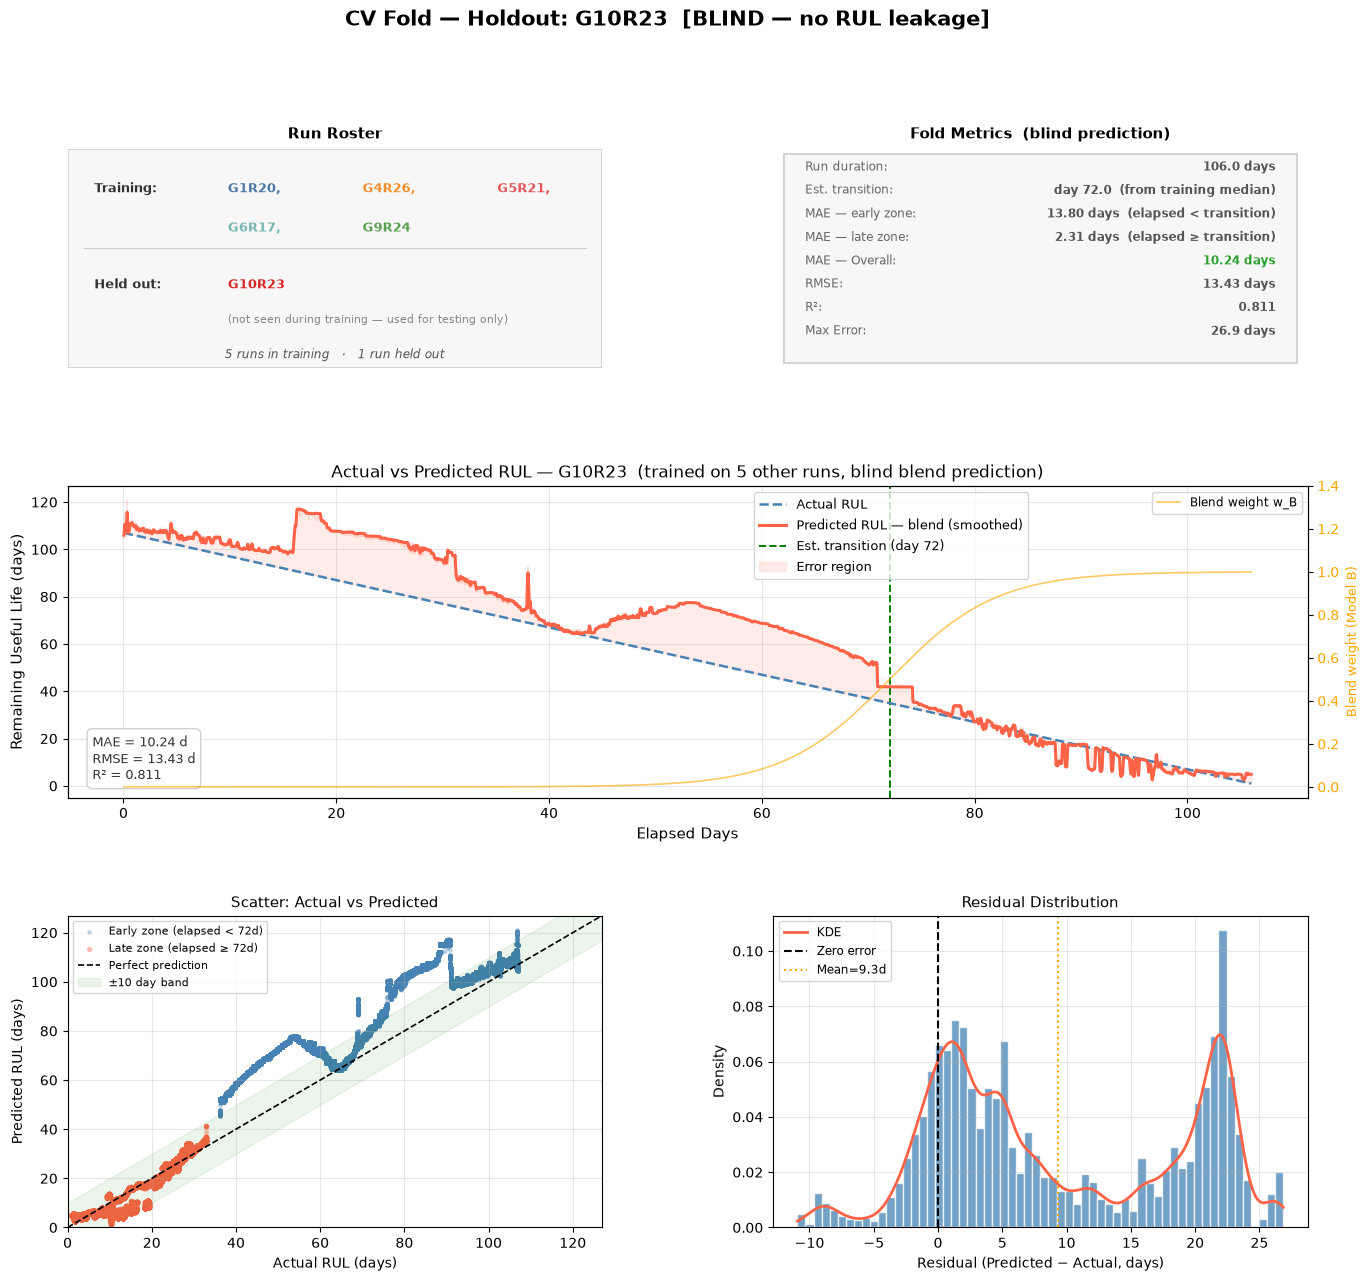

  → Plot saved: cv_fold_g10r23.png

g1r20            estimated transition ≈ 67.0 days (from 5 training runs,  range 63–93d)
                   MAE_early=15.8  MAE_late=4.7  Overall=10.9  RMSE=12.8  R²=0.864



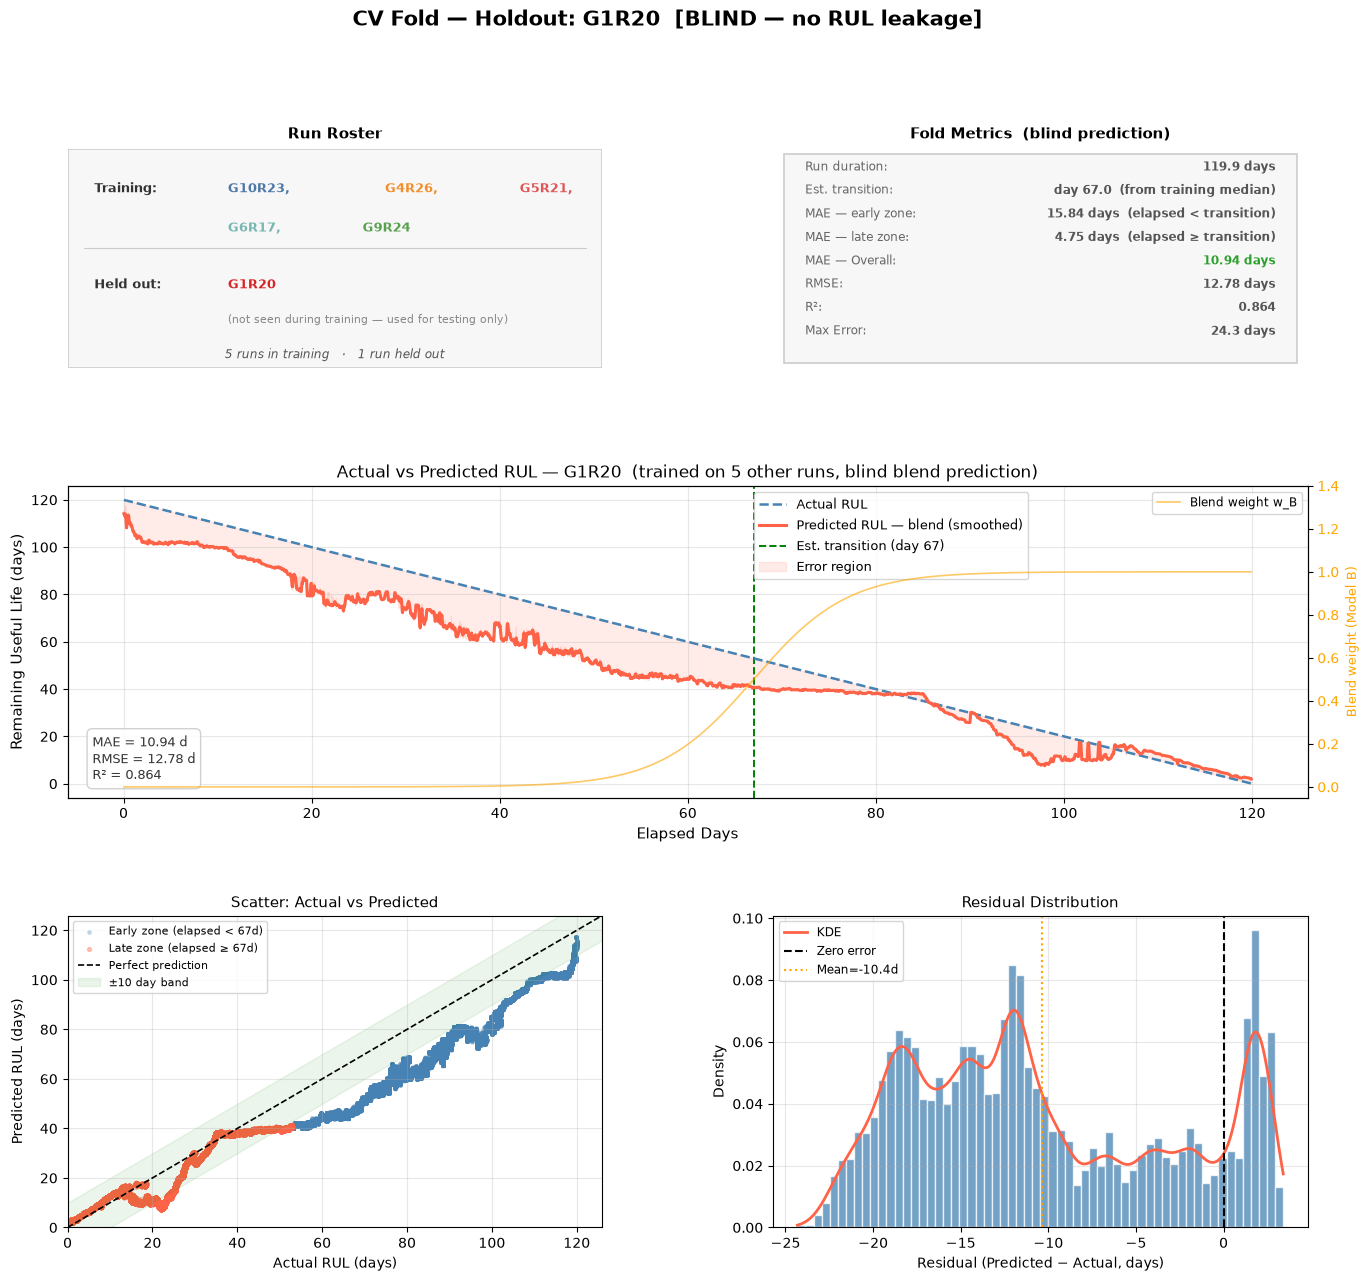

  → Plot saved: cv_fold_g1r20.png

g4r26            estimated transition ≈ 67.0 days (from 5 training runs,  range 63–80d)
                   MAE_early=27.5  MAE_late=11.1  Overall=19.6  RMSE=22.2  R²=0.667



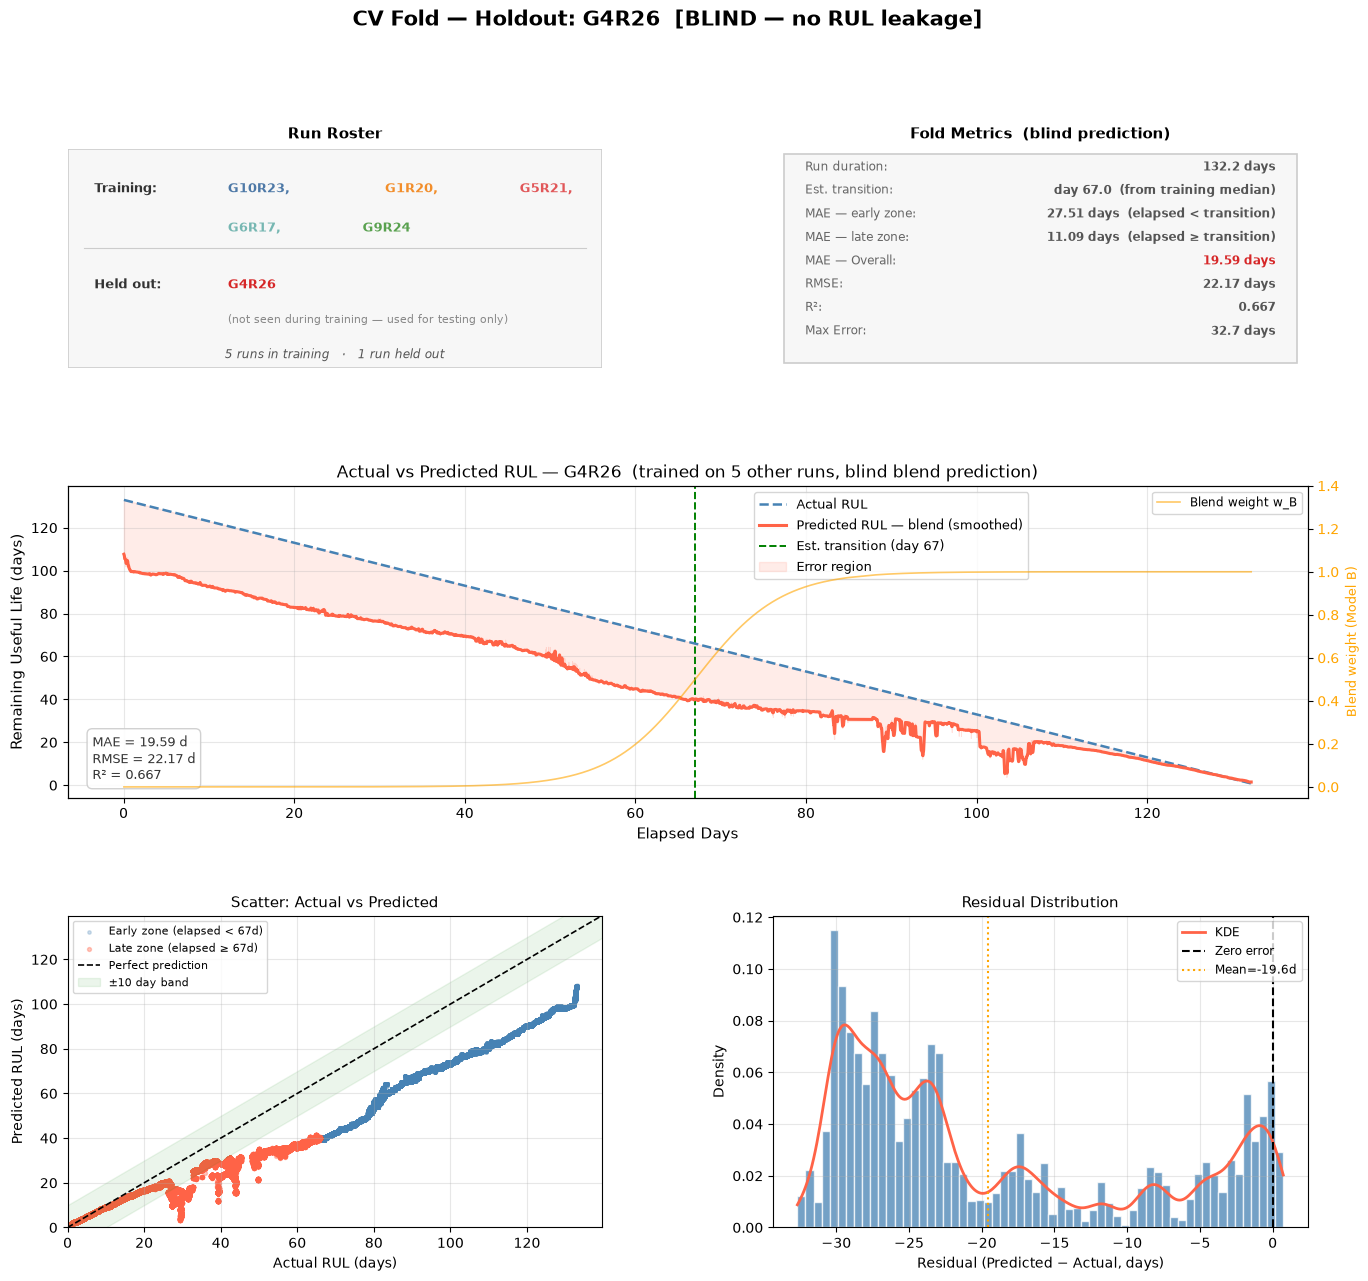

  → Plot saved: cv_fold_g4r26.png

g5r21            estimated transition ≈ 72.0 days (from 5 training runs,  range 63–93d)
                   MAE_early=11.8  MAE_late=4.8  Overall=9.6  RMSE=11.8  R²=0.846



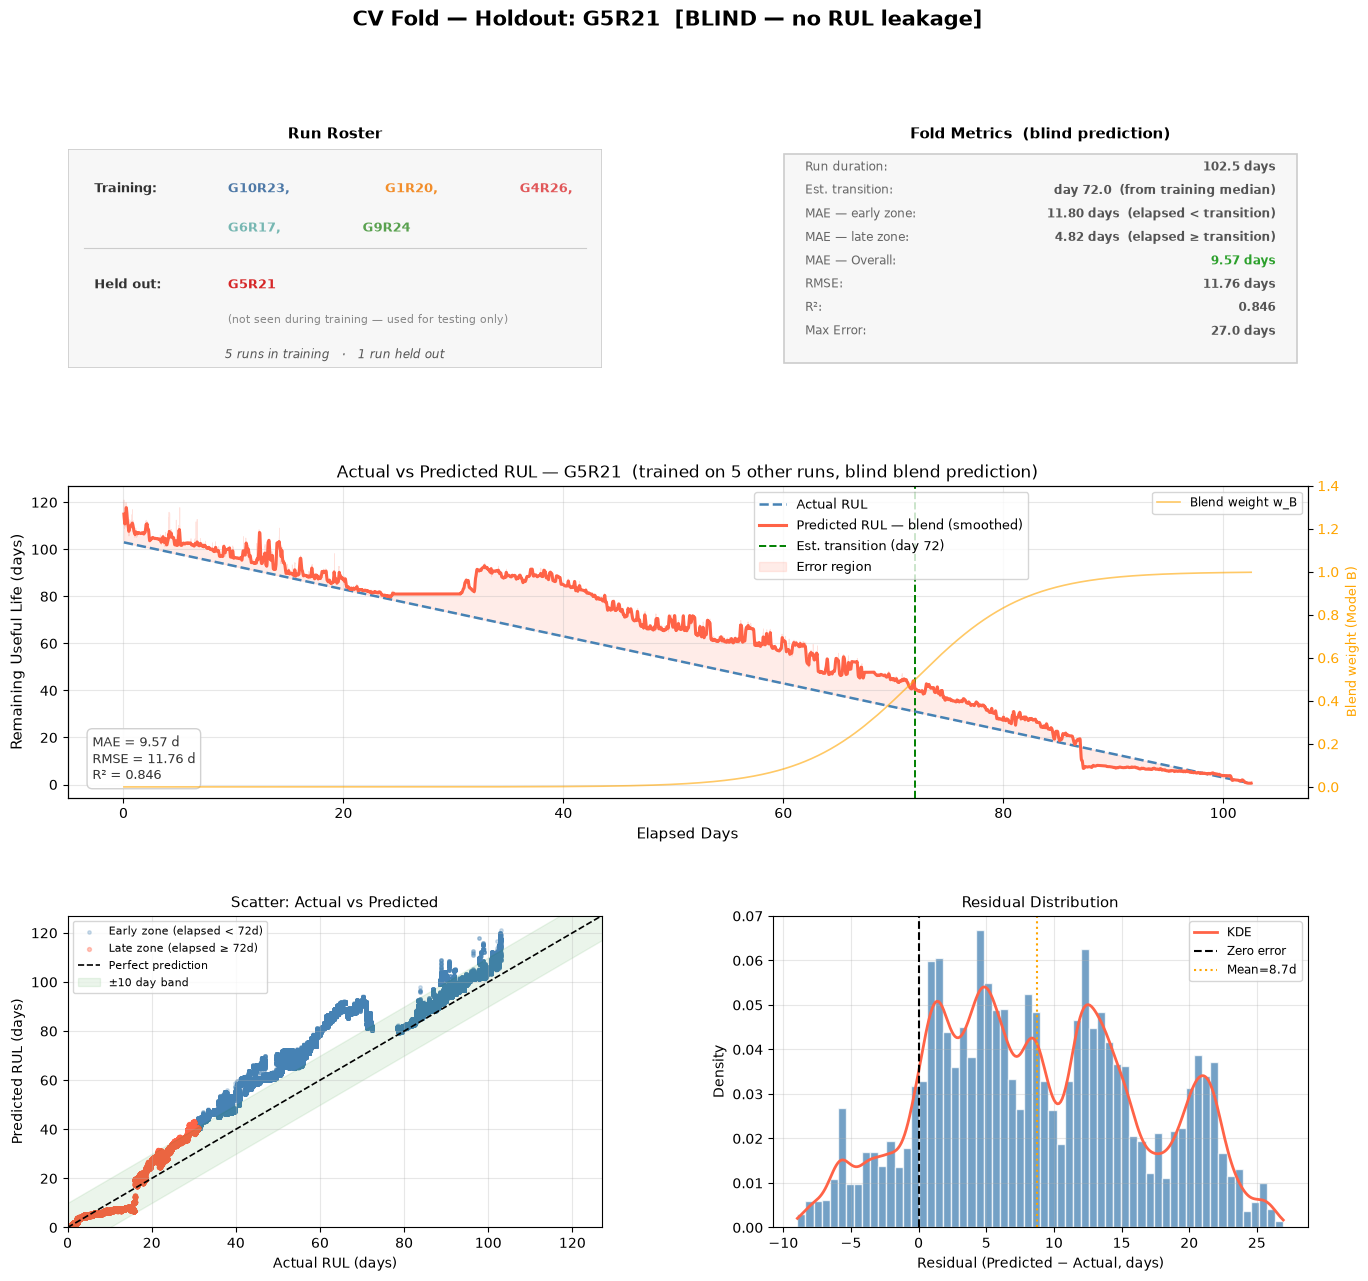

  → Plot saved: cv_fold_g5r21.png

g6r17            estimated transition ≈ 67.0 days (from 5 training runs,  range 63–93d)
                   MAE_early=6.1  MAE_late=3.0  Overall=4.9  RMSE=5.9  R²=0.966



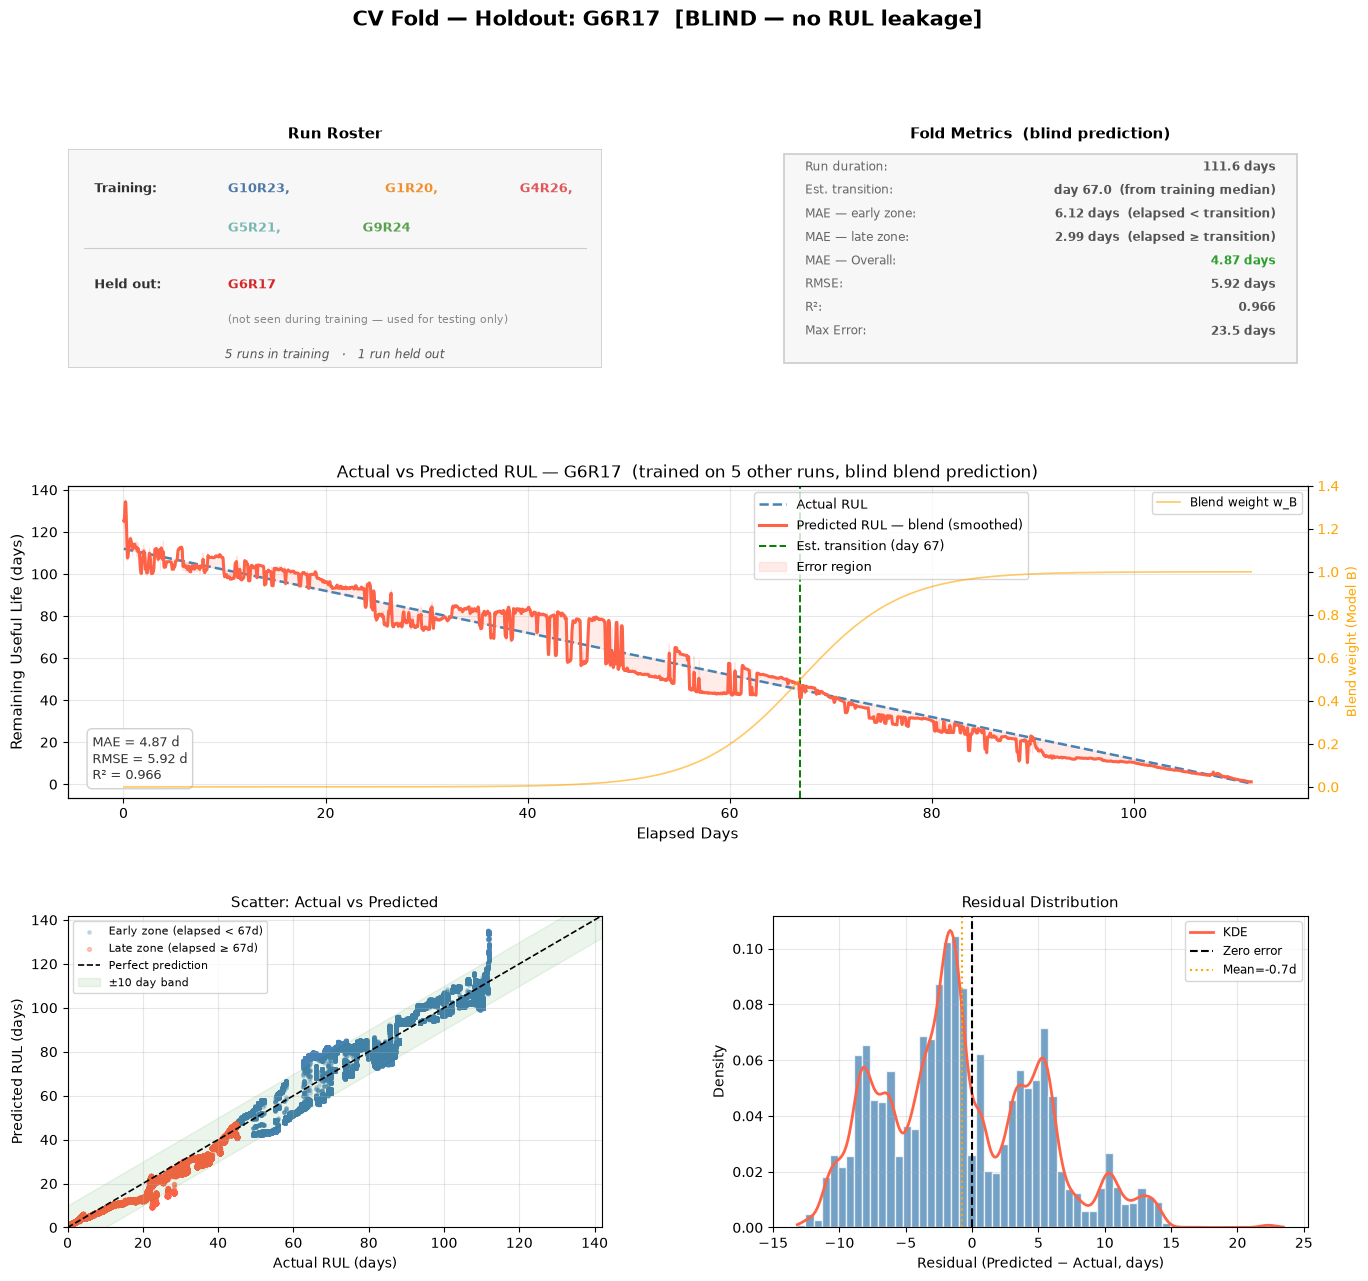

  → Plot saved: cv_fold_g6r17.png

g9r24            estimated transition ≈ 72.0 days (from 5 training runs,  range 63–93d)
                   MAE_early=9.0  MAE_late=14.9  Overall=11.6  RMSE=12.8  R²=0.856



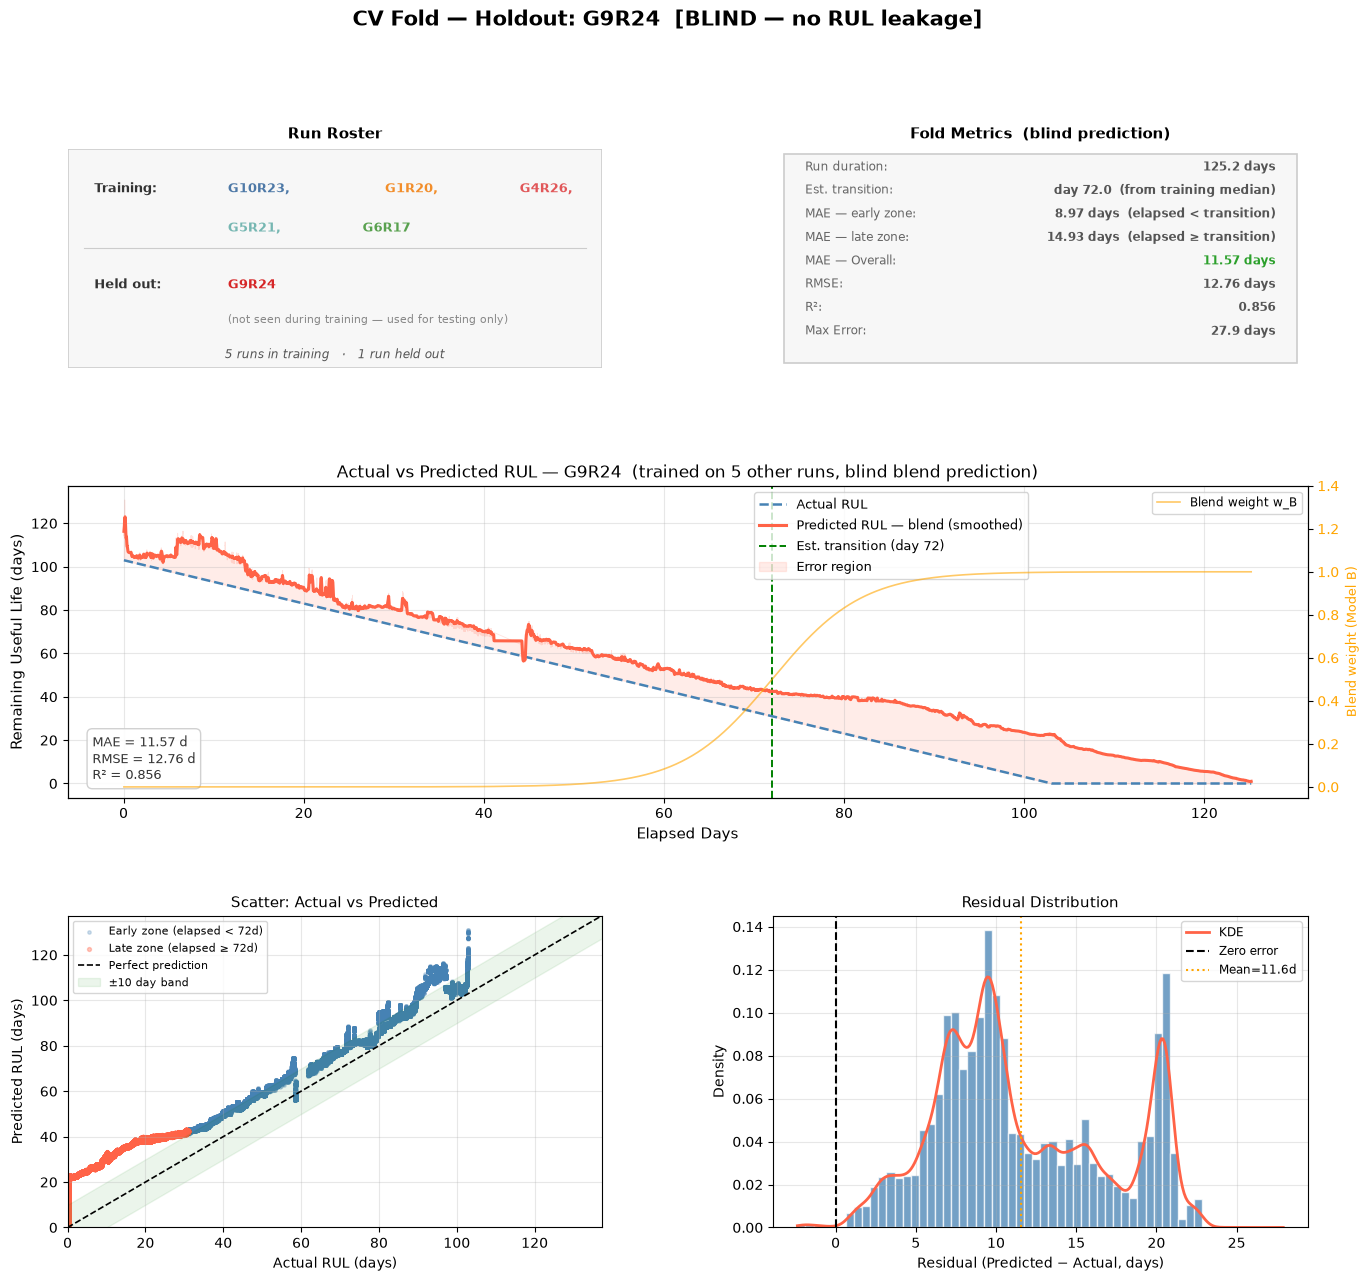

  → Plot saved: cv_fold_g9r24.png


holdout  total_days  transition  mae_early  mae_late  mae_overall  rmse    r2  max_err
 g10r23       106.0        72.0      13.80      2.31        10.24 13.43 0.811     26.9
  g1r20       119.9        67.0      15.84      4.75        10.94 12.78 0.864     24.3
  g4r26       132.2        67.0      27.51     11.09        19.59 22.17 0.667     32.7
  g5r21       102.5        72.0      11.80      4.82         9.57 11.76 0.846     27.0
  g6r17       111.6        67.0       6.12      2.99         4.87  5.92 0.966     23.5
  g9r24       125.2        72.0       8.97     14.93        11.57 12.76 0.856     27.9

Mean MAE : 11.13 days
Std  MAE : 4.78 days
Mean RMSE: 13.14 days
Mean R²  : 0.835
Best  : g6r17  (4.87d)
Worst : g4r26  (19.59d)


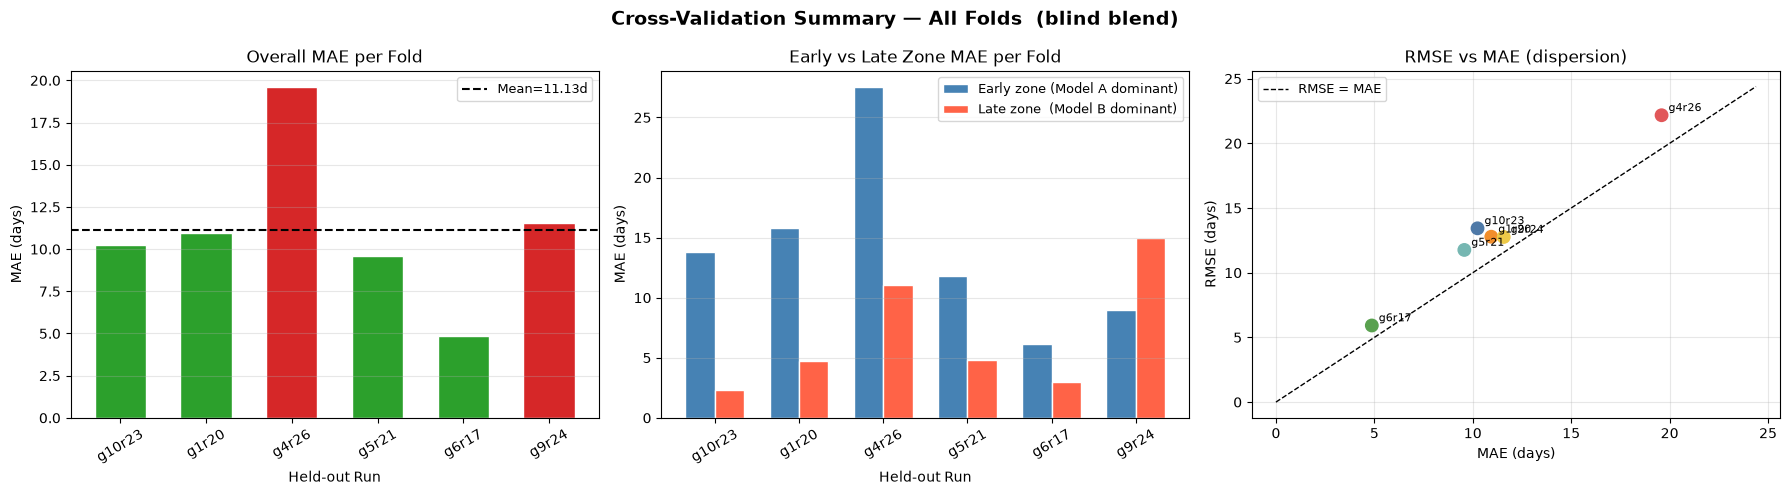

Summary plot saved → cv_summary_overview.png


In [23]:
# ── Step 4 — Cross-Validation (Leave-One-Run-Out) — FULLY BLIND (CHEAT-FREE) ─
#
# WHAT CHANGED vs the old version:
#   OLD (cheating): test_A = test_df[test_df['RUL_days'] > RUL_SPLIT]
#                   → used TRUE RUL to route rows to Model A or B
#
#   NEW (honest):   For every holdout row, only elapsed_days + sensor features
#                   are used — exactly like real inference.
#                   A sigmoid blend weight w(t) mixes Model A and B predictions
#                   based on elapsed_days crossing an ESTIMATED transition point.
#                   RUL_days is ONLY touched at the very end to compute MAE/RMSE.
#
# Blend logic mirrors inf_FINAL.ipynb exactly:
#   estimated_transition = median elapsed_days where Model B would kick in
#                        = estimated from TRAINING runs (days where RUL ≈ RUL_SPLIT)
#   w_B(t) = sigmoid((elapsed - transition) / blend_width)
#   pred(t) = (1 - w_B) * pred_A(t) + w_B * pred_B(t)
# ─────────────────────────────────────────────────────────────────────────────

from scipy.special import expit   # sigmoid: expit(x) = 1 / (1 + exp(-x))
from scipy.stats import gaussian_kde

featured = pd.read_parquet("featured_clean.parquet")

ALL_FEATURES  = [c for c in featured.columns
                 if c not in ['timestamp', 'run_id', 'RUL_days', 'elapsed_days']]
FEATURES_A    = [f for f in ALL_FEATURES if f != 'age_pct']
FEATURES_B    = ALL_FEATURES

RUNS = featured['run_id'].unique().tolist()
cv_results = []

BLEND_WIDTH = 5.0    # sigmoid steepness in days (matches inference notebook)

CHIP_COLORS = [
    '#4e79a7','#f28e2b','#e15759','#76b7b2',
    '#59a14f','#edc948','#b07aa1','#ff9da7',
    '#9c755f','#bab0ac'
]

print("Running BLIND leave-one-out cross-validation (no RUL leakage)...\n")
print(f"  Blend logic : w_B(t) = sigmoid((elapsed - transition) / {BLEND_WIDTH})")
print(f"  Transition  : estimated per fold from training runs only\n")

for holdout in RUNS:
    train_ids = [r for r in RUNS if r != holdout]
    train_df  = featured[featured['run_id'] != holdout]
    test_df   = featured[featured['run_id'] == holdout].sort_values('elapsed_days').reset_index(drop=True)

    # ── Training split uses RUL_days — this is fine, we KNOW labels in training ─
    train_A = train_df[train_df['RUL_days'] >  RUL_SPLIT].iloc[::SUBSAMPLE]
    train_B = train_df[train_df['RUL_days'] <= RUL_SPLIT].iloc[::SUBSAMPLE]

    if len(train_A) == 0 or len(train_B) == 0:
        print(f"{holdout:15s}: skipped (training set missing early or late segment)")
        cv_results.append({'holdout': holdout, 'note': 'skipped'})
        continue

    # ── Estimate transition point from TRAINING data only ────────────────────
    # For each training run: find the elapsed_days where RUL first drops to RUL_SPLIT
    # That tells us "at roughly what elapsed day does a run enter the late zone"
    transition_days = []
    for rid in train_ids:
        run = train_df[train_df['run_id'] == rid].sort_values('elapsed_days')
        cross = run[run['RUL_days'] <= RUL_SPLIT]['elapsed_days']
        if not cross.empty:
            transition_days.append(cross.iloc[0])

    if len(transition_days) == 0:
        print(f"{holdout:15s}: skipped (cannot estimate transition from training runs)")
        cv_results.append({'holdout': holdout, 'note': 'skipped'})
        continue

    # Median transition across training runs — robust to outliers
    estimated_transition = np.median(transition_days)

    print(f"{holdout:15s}  estimated transition ≈ {estimated_transition:.1f} days "
          f"(from {len(transition_days)} training runs,  "
          f"range {min(transition_days):.0f}–{max(transition_days):.0f}d)")

    # ── Train models ──────────────────────────────────────────────────────────
    mA = XGBRegressor(n_estimators=N_EST_A, learning_rate=0.05, max_depth=5,
                      subsample=0.8, colsample_bytree=0.8,
                      min_child_weight=20, random_state=42, n_jobs=-1, verbosity=0)
    mB = XGBRegressor(n_estimators=N_EST_B, learning_rate=0.05, max_depth=6,
                      subsample=0.8, colsample_bytree=0.8,
                      min_child_weight=10, random_state=42, n_jobs=-1, verbosity=0)

    mA.fit(train_A[FEATURES_A], train_A['RUL_days'])
    mB.fit(train_B[FEATURES_B], train_B['RUL_days'])

    # ── BLIND PREDICTION on all holdout rows ──────────────────────────────────
    # Both models predict every single row — then blend by elapsed_days.
    # RUL_days is never looked at here.
    raw_A = np.clip(mA.predict(test_df[FEATURES_A]), 0, None)
    raw_B = np.clip(mB.predict(test_df[FEATURES_B]), 0, None)

    # Sigmoid blend weight for Model B
    #   w_B → 0  when elapsed << transition  (pure Model A)
    #   w_B → 1  when elapsed >> transition  (pure Model B)
    w_B = expit((test_df['elapsed_days'].values - estimated_transition) / BLEND_WIDTH)
    w_A = 1.0 - w_B

    all_pred   = w_A * raw_A + w_B * raw_B
    all_actual = test_df['RUL_days'].values          # only used for scoring

    # ── Metrics ───────────────────────────────────────────────────────────────
    mae_overall  = mean_absolute_error(all_actual, all_pred)
    rmse_overall = np.sqrt(mean_squared_error(all_actual, all_pred))

    # Separate A-zone / B-zone MAE for reporting
    # Use estimated transition to define zones (still blind — same threshold)
    zone_A_mask = test_df['elapsed_days'].values < estimated_transition
    zone_B_mask = ~zone_A_mask
    mae_a = mean_absolute_error(all_actual[zone_A_mask], all_pred[zone_A_mask]) \
            if zone_A_mask.sum() > 0 else float('nan')
    mae_b = mean_absolute_error(all_actual[zone_B_mask], all_pred[zone_B_mask]) \
            if zone_B_mask.sum() > 0 else float('nan')

    ss_res = np.sum((all_actual - all_pred) ** 2)
    ss_tot = np.sum((all_actual - all_actual.mean()) ** 2)
    r2     = 1 - ss_res / ss_tot if ss_tot > 0 else float('nan')
    max_err = np.max(np.abs(all_actual - all_pred))

    print(f"  {'':15s}  MAE_early={mae_a:.1f}  MAE_late={mae_b:.1f}  "
          f"Overall={mae_overall:.1f}  RMSE={rmse_overall:.1f}  R²={r2:.3f}\n")

    cv_results.append({
        'holdout': holdout,
        'total_days':   round(test_df['elapsed_days'].max(), 1),
        'transition':   round(estimated_transition, 1),
        'mae_early':    round(mae_a, 2),
        'mae_late':     round(mae_b, 2),
        'mae_overall':  round(mae_overall, 2),
        'rmse':         round(rmse_overall, 2),
        'r2':           round(r2, 3),
        'max_err':      round(max_err, 1),
        'note': 'ok'
    })

    # ─────────────────────────────────────────────────────────────────────────
    # ── PER-FOLD PLOT ─────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(16, 14))
    fig.suptitle(
        f"CV Fold — Holdout: {holdout.upper()}  [BLIND — no RUL leakage]",
        fontsize=15, fontweight='bold', y=0.98
    )

    gs = fig.add_gridspec(3, 2, hspace=0.42, wspace=0.32,
                          height_ratios=[1.4, 2, 2])

    ax_train = fig.add_subplot(gs[0, 0])
    ax_card  = fig.add_subplot(gs[0, 1])
    ax_time  = fig.add_subplot(gs[1, :])
    ax_scat  = fig.add_subplot(gs[2, 0])
    ax_resid = fig.add_subplot(gs[2, 1])

    # ── [0,0] Run roster ──────────────────────────────────────────────────────
    ax_train.set_xlim(0, 1)
    ax_train.set_ylim(0, 1)
    ax_train.axis('off')
    bg = plt.Rectangle((0, 0), 1, 1, facecolor='#f7f7f7',
                        edgecolor='#cccccc', linewidth=1.2,
                        transform=ax_train.transAxes, zorder=0)
    ax_train.add_patch(bg)
    ax_train.set_title("Run Roster", fontsize=11, fontweight='bold', pad=8)

    ax_train.text(0.05, 0.82, "Training:", ha='left', va='center',
                  fontsize=9.5, fontweight='bold', color='#333',
                  transform=ax_train.transAxes)
    x_cursor, y_train_pos = 0.30, 0.82
    for i, rid in enumerate(train_ids):
        label = rid.upper() + ("," if i < len(train_ids) - 1 else "")
        ax_train.text(x_cursor, y_train_pos, label,
                      ha='left', va='center', fontsize=9.5, fontweight='bold',
                      color=CHIP_COLORS[i % len(CHIP_COLORS)],
                      transform=ax_train.transAxes)
        x_cursor += len(label) * 0.042
        if x_cursor > 0.94:
            x_cursor = 0.30
            y_train_pos -= 0.18

    ax_train.plot([0.03, 0.97], [0.55, 0.55],
                  color='#cccccc', linewidth=0.8, transform=ax_train.transAxes)

    ax_train.text(0.05, 0.38, "Held out:", ha='left', va='center',
                  fontsize=9.5, fontweight='bold', color='#333',
                  transform=ax_train.transAxes)
    ax_train.text(0.30, 0.38, holdout.upper(),
                  ha='left', va='center', fontsize=9.5, fontweight='bold',
                  color='#d62728', transform=ax_train.transAxes)
    ax_train.text(0.30, 0.22,
                  "(not seen during training — used for testing only)",
                  ha='left', va='center', fontsize=8, color='#888',
                  transform=ax_train.transAxes)
    ax_train.text(0.5, 0.06,
                  f"{len(train_ids)} runs in training   ·   1 run held out",
                  ha='center', va='center', fontsize=8.5, color='#555',
                  style='italic', transform=ax_train.transAxes)

    # ── [0,1] Metric card ─────────────────────────────────────────────────────
    ax_card.set_xlim(0, 1)
    ax_card.set_ylim(0, 1)
    ax_card.axis('off')
    ax_card.set_title("Fold Metrics  (blind prediction)", fontsize=11, fontweight='bold', pad=8)

    total_days_val = round(test_df['elapsed_days'].max(), 1)
    metric_lines = [
        ("Run duration",          f"{total_days_val} days"),
        ("Est. transition",       f"day {estimated_transition:.1f}  (from training median)"),
        ("MAE — early zone",      f"{mae_a:.2f} days  (elapsed < transition)"),
        ("MAE — late zone",       f"{mae_b:.2f} days  (elapsed ≥ transition)"),
        ("MAE — Overall",         f"{mae_overall:.2f} days"),
        ("RMSE",                  f"{rmse_overall:.2f} days"),
        ("R²",                    f"{r2:.3f}"),
        ("Max Error",             f"{max_err:.1f} days"),
    ]
    colors_m = ['#555'] * len(metric_lines)
    colors_m[4] = '#d62728' if mae_overall > 15 else '#2ca02c'

    card_bg = plt.Rectangle((0.02, 0.02), 0.96, 0.96,
                             facecolor='#f7f7f7', edgecolor='#cccccc',
                             linewidth=1.2, transform=ax_card.transAxes)
    ax_card.add_patch(card_bg)

    row_h = 0.86 / len(metric_lines)
    for j, ((label, val), col_m) in enumerate(zip(metric_lines, colors_m)):
        y_pos = 0.92 - j * row_h
        ax_card.text(0.06, y_pos, label + ":", ha='left', va='center',
                     fontsize=8.5, color='#666', transform=ax_card.transAxes)
        ax_card.text(0.94, y_pos, val, ha='right', va='center',
                     fontsize=8.5, fontweight='bold', color=col_m,
                     transform=ax_card.transAxes)

    # ── [1,:] Actual vs Predicted over time ───────────────────────────────────
    elapsed = test_df['elapsed_days'].values
    smooth_pred = pd.Series(all_pred).rolling(window=120, min_periods=1, center=True).mean().values

    # Actual RUL diagonal
    ax_time.plot(elapsed, all_actual,
                 color='steelblue', linewidth=1.8, linestyle='--',
                 label='Actual RUL', zorder=3)
    # Raw blend (faint)
    ax_time.plot(elapsed, all_pred,
                 color='tomato', alpha=0.18, linewidth=0.6, zorder=1)
    # Smoothed blend (bold)
    ax_time.plot(elapsed, smooth_pred,
                 color='tomato', linewidth=2.2,
                 label='Predicted RUL — blend (smoothed)', zorder=4)

    # Estimated transition line (what the model actually used)
    ax_time.axvline(x=estimated_transition, color='green', linestyle='--',
                    linewidth=1.4,
                    label=f'Est. transition (day {estimated_transition:.0f})', zorder=2)

    # Show blend weight on a secondary y-axis
    ax_twin = ax_time.twinx()
    ax_twin.plot(elapsed, w_B, color='orange', linewidth=1.2,
                 alpha=0.6, linestyle='-', label='Blend weight w_B')
    ax_twin.set_ylim(-0.05, 1.4)
    ax_twin.set_ylabel("Blend weight (Model B)", fontsize=9, color='orange')
    ax_twin.tick_params(axis='y', labelcolor='orange')
    ax_twin.legend(fontsize=8.5, loc='upper right')

    # Error region
    ax_time.fill_between(elapsed, all_actual, smooth_pred,
                         alpha=0.12, color='tomato', label='Error region')

    ax_time.annotate(
        f"MAE = {mae_overall:.2f} d\nRMSE = {rmse_overall:.2f} d\nR² = {r2:.3f}",
        xy=(0.02, 0.06), xycoords='axes fraction', fontsize=9.5, color='#333',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                  edgecolor='#ccc', alpha=0.9)
    )
    ax_time.set_xlabel("Elapsed Days", fontsize=11)
    ax_time.set_ylabel("Remaining Useful Life (days)", fontsize=11)
    ax_time.set_title(
        f"Actual vs Predicted RUL — {holdout.upper()}  "
        f"(trained on {len(train_ids)} other runs, blind blend prediction)",
        fontsize=12
    )
    ax_time.legend(fontsize=9.5, loc='upper right', bbox_to_anchor=(0.78, 1))
    ax_time.grid(True, alpha=0.3)

    # ── [2,0] Scatter: actual vs predicted, coloured by blend zone ────────────
    ax_scat.scatter(all_actual[zone_A_mask], all_pred[zone_A_mask],
                    color='steelblue', alpha=0.25, s=6,
                    label=f'Early zone (elapsed < {estimated_transition:.0f}d)')
    ax_scat.scatter(all_actual[zone_B_mask], all_pred[zone_B_mask],
                    color='tomato', alpha=0.35, s=8,
                    label=f'Late zone (elapsed ≥ {estimated_transition:.0f}d)')

    lim_max = max(all_actual.max(), all_pred.max()) * 1.05
    ax_scat.plot([0, lim_max], [0, lim_max],
                 color='black', linestyle='--', linewidth=1.2,
                 label='Perfect prediction')
    ax_scat.fill_between([0, lim_max], [10, lim_max+10], [-10, lim_max-10],
                         alpha=0.08, color='green', label='±10 day band')
    ax_scat.set_xlabel("Actual RUL (days)", fontsize=10)
    ax_scat.set_ylabel("Predicted RUL (days)", fontsize=10)
    ax_scat.set_title("Scatter: Actual vs Predicted", fontsize=11)
    ax_scat.legend(fontsize=8)
    ax_scat.grid(True, alpha=0.3)
    ax_scat.set_xlim(0, lim_max)
    ax_scat.set_ylim(0, lim_max)

    # ── [2,1] Residual distribution ───────────────────────────────────────────
    residuals = all_pred - all_actual
    ax_resid.hist(residuals, bins=60, color='steelblue', edgecolor='white',
                  alpha=0.75, density=True)
    kde_x = np.linspace(residuals.min(), residuals.max(), 300)
    kde_y = gaussian_kde(residuals)(kde_x)
    ax_resid.plot(kde_x, kde_y, color='tomato', linewidth=2, label='KDE')
    ax_resid.axvline(x=0, color='black', linewidth=1.5,
                     linestyle='--', label='Zero error')
    ax_resid.axvline(x=residuals.mean(), color='orange', linewidth=1.5,
                     linestyle=':', label=f'Mean={residuals.mean():.1f}d')
    ax_resid.set_xlabel("Residual (Predicted − Actual, days)", fontsize=10)
    ax_resid.set_ylabel("Density", fontsize=10)
    ax_resid.set_title("Residual Distribution", fontsize=11)
    ax_resid.legend(fontsize=8.5)
    ax_resid.grid(True, alpha=0.3)

    plt.savefig(f"cv_fold_{holdout}.png", dpi=110, bbox_inches='tight')
    plt.show()
    print(f"  → Plot saved: cv_fold_{holdout}.png\n")


# ── Summary table ─────────────────────────────────────────────────────────────
cv_df = pd.DataFrame(cv_results)
ok    = cv_df[cv_df['note'] == 'ok']

print(f"\n{'='*85}")
print(ok[['holdout','total_days','transition','mae_early','mae_late',
          'mae_overall','rmse','r2','max_err']].to_string(index=False))
print(f"\nMean MAE : {ok['mae_overall'].mean():.2f} days")
print(f"Std  MAE : {ok['mae_overall'].std():.2f} days")
print(f"Mean RMSE: {ok['rmse'].mean():.2f} days")
print(f"Mean R²  : {ok['r2'].mean():.3f}")
print(f"Best  : {ok.loc[ok['mae_overall'].idxmin(),'holdout']}  ({ok['mae_overall'].min():.2f}d)")
print(f"Worst : {ok.loc[ok['mae_overall'].idxmax(),'holdout']}  ({ok['mae_overall'].max():.2f}d)")


# ── FINAL SUMMARY OVERVIEW PLOT ───────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Cross-Validation Summary — All Folds  (blind blend)", fontsize=14, fontweight='bold')

bar_colors = ['#2ca02c' if m < ok['mae_overall'].mean() else '#d62728'
              for m in ok['mae_overall']]

axes2[0].bar(ok['holdout'], ok['mae_overall'], color=bar_colors, edgecolor='white', width=0.6)
axes2[0].axhline(ok['mae_overall'].mean(), color='black', linestyle='--',
                 linewidth=1.5, label=f"Mean={ok['mae_overall'].mean():.2f}d")
axes2[0].set_title("Overall MAE per Fold", fontsize=12)
axes2[0].set_ylabel("MAE (days)")
axes2[0].set_xlabel("Held-out Run")
axes2[0].tick_params(axis='x', rotation=30)
axes2[0].legend(fontsize=9)
axes2[0].grid(axis='y', alpha=0.3)

x = np.arange(len(ok))
w = 0.35
axes2[1].bar(x - w/2, ok['mae_early'], width=w, label='Early zone (Model A dominant)',
             color='steelblue', edgecolor='white')
axes2[1].bar(x + w/2, ok['mae_late'],  width=w, label='Late zone  (Model B dominant)',
             color='tomato', edgecolor='white')
axes2[1].set_xticks(x)
axes2[1].set_xticklabels(ok['holdout'], rotation=30)
axes2[1].set_title("Early vs Late Zone MAE per Fold", fontsize=12)
axes2[1].set_ylabel("MAE (days)")
axes2[1].set_xlabel("Held-out Run")
axes2[1].legend(fontsize=9)
axes2[1].grid(axis='y', alpha=0.3)

axes2[2].scatter(ok['mae_overall'], ok['rmse'], s=80, zorder=3,
                 color=[CHIP_COLORS[i % len(CHIP_COLORS)] for i in range(len(ok))])
for _, row in ok.iterrows():
    axes2[2].annotate(row['holdout'], (row['mae_overall'], row['rmse']),
                      textcoords='offset points', xytext=(5, 3), fontsize=8)
lim = max(ok['rmse'].max(), ok['mae_overall'].max()) * 1.1
axes2[2].plot([0, lim], [0, lim], 'k--', linewidth=1, label='RMSE = MAE')
axes2[2].set_xlabel("MAE (days)")
axes2[2].set_ylabel("RMSE (days)")
axes2[2].set_title("RMSE vs MAE (dispersion)", fontsize=12)
axes2[2].legend(fontsize=9)
axes2[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("cv_summary_overview.png", dpi=110, bbox_inches='tight')
plt.show()
print("Summary plot saved → cv_summary_overview.png")

# Testing on a Single Run

In [24]:
# import pandas as pd
# import numpy as np
# import joblib

# BUNDLE_PATH  = r"D:\E-minds projects\Fix before fail\fresh\rul_bundle_v5.joblib"
# PARQUET_PATH = "featured_clean.parquet"
# RUN_ID       = "g1r20"
# TOTAL_DAYS   = 119.86
# START_PCT    = 0.70
# WINDOW_ROWS  = 60

# # Load bundle
# bundle     = joblib.load(BUNDLE_PATH)
# model_A    = bundle['model_A']
# model_B    = bundle['model_B']
# FEATURES_A = bundle['features_A']
# FEATURES_B = bundle['features_B']
# SENSORS    = bundle['sensors']
# RUL_SPLIT  = bundle['rul_split']

# # Load EXACT featured rows — same source as Monte Carlo
# featured  = pd.read_parquet(PARQUET_PATH)
# run_feat  = featured[featured['run_id'] == RUN_ID].reset_index(drop=True)

# # Find 70% cutoff
# cutoff_day  = TOTAL_DAYS * START_PCT
# w_start     = int(run_feat[run_feat['elapsed_days'] >= cutoff_day].index[0])
# w_end       = w_start + WINDOW_ROWS

# # Slice exact 60 rows — identical to Monte Carlo
# window_feat = run_feat.iloc[w_start:w_end].reset_index(drop=True)
# actual_rul  = run_feat['RUL_days'].iloc[w_start]

# print(f"Cutoff day   : {run_feat['elapsed_days'].iloc[w_start]:.2f}")
# print(f"Actual RUL   : {actual_rul:.4f} days")

# # Predict
# preds_A = np.clip(model_A.predict(
#     window_feat.reindex(columns=FEATURES_A, fill_value=0)), 0, None)
# preds_B = np.clip(model_B.predict(
#     window_feat.reindex(columns=FEATURES_B, fill_value=0)), 0, None)

# def get_blend_weight(a, hi=60, lo=30):
#     if a >= hi:  return 0.0
#     elif a <= lo: return 1.0
#     else: return 1.0 - (a - lo) / (hi - lo)

# weights   = np.array([get_blend_weight(a) for a in preds_A])
# blended   = (1 - weights) * preds_A + weights * preds_B

# est_blend = float(blended.mean())
# w_b_mean  = float(weights.mean())

# print(f"\n{'='*50}")
# print(f"  Blended RUL      : {est_blend:.4f} days")
# print(f"  Blend weight (B) : {w_b_mean:.3f}")
# print(f"  Monte Carlo says : 38.7140 days")
# print(f"  Match            : "
#       f"{'✓ YES' if abs(est_blend - 38.714) < 0.1 else '✗ check parquet'}")
# print(f"{'='*50}")

# # Store for transform cell
# BASELINE_RUL   = est_blend
# WINDOW_SENSORS = run_feat.iloc[w_start:w_end][SENSORS].values.astype(float)
# WINDOW_FEAT    = window_feat
# CUTOFF_ROW     = w_start
# print(f"\nBASELINE_RUL   : {BASELINE_RUL:.4f}")
# print(f"WINDOW_SENSORS : {WINDOW_SENSORS.shape}  ← raw sensors for B-matrix")
# print(f"WINDOW_FEAT    : {WINDOW_FEAT.shape}   ← featured rows for re-prediction")

## Step 4b — Transformation Analysis (Blend-Start Windows)

In [25]:
# ── 1. B-matrix paths — FILL IN YOUR PATHS ───────────────────────────────────
BMAT_PATHS = {
    "g1r20":      r"D:\E-minds projects\Fix before fail\datasets\g1r20 original\g1r20_buc-late_BM_15__lam0.01-lmin5-lmax15.xlsx",   # ← paste path to g1r20 bmat .xlsx
    "g4r26":      r"D:\E-minds projects\Fix before fail\datasets\g4r26 original\g4r26_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
    "g5r19":      r"D:\E-minds projects\Fix before fail\datasets\g5r19 original\g5r19_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
    "g5r21":      r"D:\E-minds projects\Fix before fail\datasets\g5r21 original\g5r21_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
    "g6r17":      r"D:\E-minds projects\Fix before fail\datasets\g6r17 original\g6r17_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
    "g9r24":      r"D:\E-minds projects\Fix before fail\datasets\g9r24 original\g9r24_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
    "g10r23":     r"D:\E-minds projects\Fix before fail\datasets\g10r23 original\g10r23_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
}

In [26]:
# # ── Step 4b — B-matrix Random Search for RUL Improvement (single window) ────
# import pandas as pd
# import numpy as np
# import joblib
# import warnings
# import os
# import time
# import sys
# from datetime import datetime
# warnings.filterwarnings('ignore')

# # ── Custom Logger to Mirror Terminal to Files ─────────────────────────────────
# class DualLogger(object):
#     def __init__(self, filenames):
#         self.terminal = sys.stdout
#         # Open files in append mode with explicit encoding
#         self.files = [open(f, "a", encoding="utf-8") for f in filenames]

#     def write(self, message):
#         self.terminal.write(message)
#         for f in self.files:
#             f.write(message)
#             f.flush()

#     def flush(self):
#         self.terminal.flush()
#         for f in self.files:
#             f.flush()

#     def close_files(self):
#         for f in self.files:
#             try:
#                 f.close()
#             except:
#                 pass

# # ── 0. Load model bundle ──────────────────────────────────────────────────────
# bundle     = joblib.load(BUNDLE_PATH)
# model_A    = bundle['model_A']
# model_B    = bundle['model_B']
# FEATURES_A = bundle['features_A']
# FEATURES_B = bundle['features_B']
# RUL_SPLIT  = bundle['rul_split']
# print(f"Bundle loaded  (RUL_SPLIT={RUL_SPLIT}d)")

# # ── 1. B-matrix paths ─────────────────────────────────────────────────────────
# BMAT_PATHS = {
#     "g1r20":  r"D:\E-minds projects\Fix before fail\datasets\g1r20 original\g1r20_buc-late_BM_15__lam0.01-lmin5-lmax15.xlsx",
#     "g4r26":  r"D:\E-minds projects\Fix before fail\datasets\g4r26 original\g4r26_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g5r19":  r"D:\E-minds projects\Fix before fail\datasets\g5r19 original\g5r19_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g5r21":  r"D:\E-minds projects\Fix before fail\datasets\g5r21 original\g5r21_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g6r17":  r"D:\E-minds projects\Fix before fail\datasets\g6r17 original\g6r17_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g9r24":  r"D:\E-minds projects\Fix before fail\datasets\g9r24 original\g9r24_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g10r23": r"D:\E-minds projects\Fix before fail\datasets\g10r23 original\g10r23_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
# }

# # ── 2. Config ─────────────────────────────────────────────────────────────────
# WINDOW_ROWS   = 60
# ITERATIONS    = 10
# START_PCT     = 0.85
# N_TRIALS      = 20000
# LOG_DIR       = "bmat_search_logs_neg2_pos2_20k_85pct_crosscheck_7pm"
# PERTURB_CELLS = [(1,0), (0,1), (4,0), (0,4), (4,1), (1,4)]
# TOP_N_IN_ALL  = 20
# THRESHOLDS    = sorted([5, 10, 20])   # e.g. [1, 5, 20, 30] — fully dynamic

# os.makedirs(LOG_DIR, exist_ok=True)

# # ── 3. Core math ──────────────────────────────────────────────────────────────
# def simulate_row(X, B_orig, B_sim, iterations=10):
#     I         = np.eye(len(X))
#     Y         = (I - B_orig.T) @ X
#     X_current = np.linalg.inv(I - B_sim.T) @ Y
#     for _ in range(iterations):
#         X_current = B_sim.T @ X_current + Y
#     return X_current

# def load_bmat(path):
#     return pd.read_excel(path).values.astype(float)

# def recompute_features_for_window(window_raw, full_run_featured, start_idx, end_idx):
#     slice_feat = full_run_featured.iloc[start_idx:end_idx].copy()
#     for i, s in enumerate(SENSORS):
#         slice_feat[s] = window_raw[:, i]
#         mid = full_run_featured[s].iloc[
#             len(full_run_featured)//4 : 3*len(full_run_featured)//4
#         ]
#         med = mid.median()
#         std = mid.std()
#         std = std if std > 1e-9 else 1.0
#         slice_feat[f'{s}_dev'] = (slice_feat[s] - med) / std
#     return slice_feat

# def get_blend_weight(est_a, blend_high=60, blend_low=30):
#     if est_a >= blend_high:  return 0.0
#     elif est_a <= blend_low: return 1.0
#     else: return 1.0 - (est_a - blend_low) / (blend_high - blend_low)

# def predict_from_slice(slice_feat):
#     recent = slice_feat.tail(WINDOW_ROWS)
#     feat_a = recent.reindex(columns=FEATURES_A, fill_value=0)
#     feat_b = recent.reindex(columns=FEATURES_B, fill_value=0)
#     est_a  = float(np.clip(model_A.predict(feat_a), 0, None).mean())
#     est_b  = float(np.clip(model_B.predict(feat_b), 0, None).mean())
#     w_b    = get_blend_weight(est_a)
#     return (1 - w_b) * est_a + w_b * est_b

# def format_hit_line(trial, pct_imp, days_imp, baseline_rul, rul_sim, threshold_str, new_vals):
#     cell_str = "  ".join(f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, new_vals))
#     return (
#         f"{trial:>7}   {pct_imp:>+7.2f}% ({days_imp:>+6.2f}d)   "
#         f"{baseline_rul:>10.4f}   {rul_sim:>10.4f}   "
#         f"{threshold_str:>10}   {cell_str}"
#     )

# def build_summary(run_id, n_trials, n_hits, elapsed):
#     lines = [f"\nSummary for {run_id.upper()}:"]
#     lines.append(f"  Trials run   : {n_trials}")
#     lines.append(f"  Time elapsed : {elapsed:.1f}s")
#     lines.append(f"  {'Threshold':<12}   {'Hits':>6}   {'Hit %':>8}")
#     lines.append(f"  {'-'*32}")
#     for t in THRESHOLDS:
#         hits   = n_hits[t]
#         hit_pct = hits / n_trials * 100
#         lines.append(f"  >{t:<11}   {hits:>6}   {hit_pct:>7.2f}%")
#     lines.append("-" * 80)
#     return "\n".join(lines)

# # ── 4. Main loop ──────────────────────────────────────────────────────────────
# featured = pd.read_parquet("featured_clean.parquet")
# RUNS     = [r for r in featured['run_id'].unique() if BMAT_PATHS.get(r, "")]

# all_log_path = os.path.join(LOG_DIR, "improvement_log_ALL.txt")

# # Clear global log before starting fresh
# with open(all_log_path, "w", encoding="utf-8") as f:
#     pass

# # Initialize global layout details inside original terminal format
# print("B-MATRIX RANDOM SEARCH LOG")
# print(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
# print(f"Trials/run : {N_TRIALS}    Window : {WINDOW_ROWS} rows at {START_PCT*100:.0f}% cutoff")
# print(f"Perturb    : {PERTURB_CELLS}")
# print(f"Thresholds : {THRESHOLDS}")
# print(f"All-log    : top {TOP_N_IN_ALL} hits per run only")
# print("=" * 100)

# # Append this initial block to the global file manually before stdout redirection
# with open(all_log_path, "a", encoding="utf-8") as f:
#     f.write(f"B-MATRIX RANDOM SEARCH LOG\n")
#     f.write(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
#     f.write(f"Trials/run : {N_TRIALS}    Window : {WINDOW_ROWS} rows at {START_PCT*100:.0f}% cutoff\n")
#     f.write(f"Perturb    : {PERTURB_CELLS}\n")
#     f.write(f"Thresholds : {THRESHOLDS}\n")
#     f.write(f"All-log    : top {TOP_N_IN_ALL} hits per run only\n")
#     f.write("=" * 100 + "\n")

# for run_id in RUNS:
#     run_feat = featured[featured['run_id'] == run_id].reset_index(drop=True)
#     run_log_path = os.path.join(LOG_DIR, f"improvement_log_{run_id}.txt")
    
#     # Reset per-run file
#     with open(run_log_path, "w", encoding="utf-8") as f:
#         pass

#     # Save original stdout to restore it later
#     original_stdout = sys.stdout
    
#     # Intercept all prints and duplicate to both files and screen
#     sys.stdout = DualLogger([all_log_path, run_log_path])

#     print(f"\n{'=' * 75}")
#     print(f"Run: {run_id.upper()}  ({len(run_feat):,} rows)")

#     bmat_file_path = BMAT_PATHS[run_id]
#     try:
#         B_ORIGINAL = load_bmat(bmat_file_path)
#         print(f"  B-matrix loaded from: {bmat_file_path}  shape={B_ORIGINAL.shape}")
#     except Exception as e:
#         print(f"  Could not load B-matrix from {bmat_file_path}: {e} -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     # ── Find 70% cutoff row ───────────────────────────────────────────────────
#     total_duration = run_feat['elapsed_days'].iloc[-1]
#     cutoff_rows    = np.where(run_feat['elapsed_days'] >= START_PCT * total_duration)[0]
#     if len(cutoff_rows) == 0:
#         print(f"  Could not find 70% cutoff -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     w_start           = int(cutoff_rows[0])
#     w_end             = w_start + WINDOW_ROWS
#     if w_end > len(run_feat):
#         print(f"  Not enough rows after 70% cutoff -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     actual_cutoff_day = run_feat['elapsed_days'].iloc[w_start]
#     rul_at_cutoff     = (run_feat['RUL_days'].iloc[w_start]
#                          if 'RUL_days' in run_feat.columns else float('nan'))

#     print(f"  Total duration : {total_duration:.1f}d   "
#           f"70% cutoff : day {actual_cutoff_day:.1f}  "
#           f"(rows {w_start:,} to {w_end:,})   Actual RUL : {rul_at_cutoff:.1f}d")

#     # ── Baseline ──────────────────────────────────────────────────────────────
#     window_sensors = run_feat.iloc[w_start:w_end][SENSORS].values.astype(float)
#     if np.isnan(window_sensors).sum() > 0:
#         print(f"  NaNs in window -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     baseline_rul = predict_from_slice(run_feat.iloc[w_start:w_end])
#     print(f"  Baseline RUL (original, no transform) : {baseline_rul:.4f} days")
#     print(f"  Starting {N_TRIALS} trials ...")

#     header_line = (
#         f"{'Trial':>7}   {'ImpPct (Days)':>18}   {'RUL_orig':>10}   {'RUL_sim':>10}   "
#         f"{'Threshold':>10}   Cell_values_(r,c)=val ..."
#     )

#     print("-" * 100)
#     print(header_line)
#     print("-" * 100)

#     n_hits     = {t: 0 for t in THRESHOLDS}
#     t_start    = time.time()
#     best_ever  = {"pct": -np.inf, "days": -np.inf, "rul_sim": None, "trial": None, "vals": None}
#     worst_ever = {"pct": np.inf, "days": np.inf, "rul_sim": None, "trial": None, "vals": None}
#     top_hits   = []   

#     for trial in range(1, N_TRIALS + 1):
#         # Sampling bounded by user instructions (-1 to 1 or custom parameters)
#         new_vals = np.random.uniform(-2, 2, size=len(PERTURB_CELLS))
#         B_SIM    = B_ORIGINAL.copy()
#         for (r, c), v in zip(PERTURB_CELLS, new_vals):
#             B_SIM[r, c] = v

#         transformed = np.apply_along_axis(
#             simulate_row, axis=1, arr=window_sensors,
#             B_orig=B_ORIGINAL, B_sim=B_SIM, iterations=ITERATIONS
#         )

#         slice_after = recompute_features_for_window(transformed, run_feat, w_start, w_end)
#         rul_sim     = predict_from_slice(slice_after)
        
#         days_imp    = rul_sim - baseline_rul
#         pct_imp     = (days_imp) / baseline_rul * 100

#         # ── Track best ever ───────────────────────────────────────────────────
#         if pct_imp > best_ever["pct"]:
#             best_ever = {"pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
#                          "trial": trial, "vals": new_vals.copy()}

#         # ── Track worst ever ──────────────────────────────────────────────────
#         if pct_imp < worst_ever["pct"]:
#             worst_ever = {"pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
#                           "trial": trial, "vals": new_vals.copy()}

#         # ── Threshold hits ────────────────────────────────────────────────────
#         hit_thresholds = [t for t in THRESHOLDS if pct_imp > t]
#         if hit_thresholds:
#             for t in hit_thresholds:
#                 n_hits[t] += 1
#             threshold_str = f">{max(hit_thresholds)}%"
#             line = format_hit_line(trial, pct_imp, days_imp, baseline_rul, rul_sim, threshold_str, new_vals)
#             print(line)
#             top_hits.append((pct_imp, line))

#         if trial % 500 == 0:
#             elapsed  = time.time() - t_start
#             eta      = (elapsed / trial) * (N_TRIALS - trial)
#             hits_str = "  ".join(f"hits>{t}%: {n_hits[t]}" for t in THRESHOLDS)
#             print(f"  [{run_id}] Trial {trial:>5}/{N_TRIALS}  {hits_str}  "
#                   f"best: {best_ever['pct']:>+6.2f}% ({best_ever['days']:>+5.2f}d)  ETA: {eta:.1f}s")

#     elapsed_total = time.time() - t_start

#     # ── Performance Blocks ────────────────────────────────────────────────────
#     best_cell_str = "  ".join(
#         f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, best_ever["vals"])
#     )
#     print(f"\n  Best-ever trial  : #{best_ever['trial']}")
#     print(f"  Improvement      : {best_ever['pct']:>+.2f}% ({best_ever['days']:>+.4f} days)")
#     print(f"  RUL simulated    : {best_ever['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)")
#     print(f"  Cell values      : {best_cell_str}")

#     worst_cell_str = "  ".join(
#         f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, worst_ever["vals"])
#     )
#     print(f"\n  Worst-ever trial : #{worst_ever['trial']}")
#     print(f"  Degradation      : {worst_ever['pct']:>+.2f}% ({worst_ever['days']:>+.4f} days)")
#     print(f"  RUL simulated    : {worst_ever['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)")
#     print(f"  Cell values      : {worst_cell_str}")

#     summary = build_summary(run_id, N_TRIALS, n_hits, elapsed_total)
#     print(summary)

#     hits_str = "  ".join(f"hits>{t}%: {n_hits[t]}" for t in THRESHOLDS)
    
#     # Restore normal terminal stdout before tracking logs metadata paths
#     sys.stdout.close_files()
#     sys.stdout = original_stdout

#     print(f"  Done in {elapsed_total:.1f}s  --  {hits_str}\n"
#           f"  best: {best_ever['pct']:>+.2f}% ({best_ever['days']:>+.2f}d) [Trial #{best_ever['trial']}]\n"
#           f"  worst: {worst_ever['pct']:>+.2f}% ({worst_ever['days']:>+.2f}d) [Trial #{worst_ever['trial']}]")
#     print(f"  Log -> {run_log_path}")

# print(f"\nAll logs -> {all_log_path}")

# Montecarlo sim, shared trail

In [ ]:
# # ── Step 4b — B-matrix Random Search for RUL Improvement (single window) ────
# # Same set of perturbation VALUES applied consistently across ALL gasifiers per trial
# import pandas as pd
# import numpy as np
# import joblib
# import warnings
# import os
# import time
# import sys
# from datetime import datetime
# warnings.filterwarnings('ignore')

# # ── Custom Logger to Mirror Terminal to Files ─────────────────────────────────
# class DualLogger(object):
#     def __init__(self, filenames):
#         self.terminal = sys.stdout
#         self.files = [open(f, "a", encoding="utf-8") for f in filenames]

#     def write(self, message):
#         self.terminal.write(message)
#         for f in self.files:
#             f.write(message)
#             f.flush()

#     def flush(self):
#         self.terminal.flush()
#         for f in self.files:
#             f.flush()

#     def close_files(self):
#         for f in self.files:
#             try:
#                 f.close()
#             except:
#                 pass

# # ── 0. Load model bundle ──────────────────────────────────────────────────────
# bundle     = joblib.load(BUNDLE_PATH)
# model_A    = bundle['model_A']
# model_B    = bundle['model_B']
# FEATURES_A = bundle['features_A']
# FEATURES_B = bundle['features_B']
# RUL_SPLIT  = bundle['rul_split']
# print(f"Bundle loaded  (RUL_SPLIT={RUL_SPLIT}d)")

# # ── 1. B-matrix paths ─────────────────────────────────────────────────────────
# BMAT_PATHS = {
#     "g1r20":  r"D:\E-minds projects\Fix before fail\datasets\g1r20 original\g1r20_buc-late_BM_15__lam0.01-lmin5-lmax15.xlsx",
#     "g4r26":  r"D:\E-minds projects\Fix before fail\datasets\g4r26 original\g4r26_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g5r19":  r"D:\E-minds projects\Fix before fail\datasets\g5r19 original\g5r19_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g5r21":  r"D:\E-minds projects\Fix before fail\datasets\g5r21 original\g5r21_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g6r17":  r"D:\E-minds projects\Fix before fail\datasets\g6r17 original\g6r17_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g9r24":  r"D:\E-minds projects\Fix before fail\datasets\g9r24 original\g9r24_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g10r23": r"D:\E-minds projects\Fix before fail\datasets\g10r23 original\g10r23_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
# }

# # ── 2. Config ─────────────────────────────────────────────────────────────────
# WINDOW_ROWS   = 60
# ITERATIONS    = 10
# START_PCT     = 0.85
# N_TRIALS      = 20000
# LOG_DIR       = "bmat_search_logs_neg1_pos1_20k_85pct_shared_trials-10-38-AM"
# PERTURB_CELLS = [(1,0), (0,1), (4,0), (0,4), (4,1), (1,4)]   # fixed cell list, ALL gasifiers
# TOP_N_IN_ALL  = 20
# THRESHOLDS    = sorted([5, 10, 20])

# os.makedirs(LOG_DIR, exist_ok=True)

# # ── 3. Core math ──────────────────────────────────────────────────────────────
# def simulate_row(X, B_orig, B_sim, iterations=10):
#     I         = np.eye(len(X))
#     Y         = (I - B_orig.T) @ X
#     X_current = np.linalg.inv(I - B_sim.T) @ Y
#     for _ in range(iterations):
#         X_current = B_sim.T @ X_current + Y
#     return X_current

# def load_bmat(path):
#     return pd.read_excel(path).values.astype(float)

# def recompute_features_for_window(window_raw, full_run_featured, start_idx, end_idx):
#     slice_feat = full_run_featured.iloc[start_idx:end_idx].copy()
#     for i, s in enumerate(SENSORS):
#         slice_feat[s] = window_raw[:, i]
#         mid = full_run_featured[s].iloc[
#             len(full_run_featured)//4 : 3*len(full_run_featured)//4
#         ]
#         med = mid.median()
#         std = mid.std()
#         std = std if std > 1e-9 else 1.0
#         slice_feat[f'{s}_dev'] = (slice_feat[s] - med) / std
#     return slice_feat

# def get_blend_weight(est_a, blend_high=60, blend_low=30):
#     if est_a >= blend_high:  return 0.0
#     elif est_a <= blend_low: return 1.0
#     else: return 1.0 - (est_a - blend_low) / (blend_high - blend_low)

# def predict_from_slice(slice_feat):
#     recent = slice_feat.tail(WINDOW_ROWS)
#     feat_a = recent.reindex(columns=FEATURES_A, fill_value=0)
#     feat_b = recent.reindex(columns=FEATURES_B, fill_value=0)
#     est_a  = float(np.clip(model_A.predict(feat_a), 0, None).mean())
#     est_b  = float(np.clip(model_B.predict(feat_b), 0, None).mean())
#     w_b    = get_blend_weight(est_a)
#     return (1 - w_b) * est_a + w_b * est_b

# def format_hit_line(trial, pct_imp, days_imp, baseline_rul, rul_sim, threshold_str, new_vals):
#     cell_str = "  ".join(f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, new_vals))
#     return (
#         f"{trial:>7}   {pct_imp:>+7.2f}% ({days_imp:>+6.2f}d)   "
#         f"{baseline_rul:>10.4f}   {rul_sim:>10.4f}   "
#         f"{threshold_str:>10}   {cell_str}"
#     )

# def build_summary(run_id, n_trials, n_hits, elapsed):
#     lines = [f"\nSummary for {run_id.upper()}:"]
#     lines.append(f"  Trials run   : {n_trials}")
#     lines.append(f"  Time elapsed : {elapsed:.1f}s")
#     lines.append(f"  {'Threshold':<12}   {'Hits':>6}   {'Hit %':>8}")
#     lines.append(f"  {'-'*32}")
#     for t in THRESHOLDS:
#         hits   = n_hits[t]
#         hit_pct = hits / n_trials * 100
#         lines.append(f"  >{t:<11}   {hits:>6}   {hit_pct:>7.2f}%")
#     lines.append("-" * 80)
#     return "\n".join(lines)

# # ── 4. Pre-load all gasifiers' static data (B-matrix, window, baseline) ───────
# featured = pd.read_parquet("featured_clean.parquet")
# RUNS     = [r for r in featured['run_id'].unique() if BMAT_PATHS.get(r, "")]

# all_log_path = os.path.join(LOG_DIR, "improvement_log_ALL.txt")
# with open(all_log_path, "w", encoding="utf-8") as f:
#     pass

# print("B-MATRIX RANDOM SEARCH LOG  (shared trial values across all gasifiers)")
# print(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
# print(f"Trials     : {N_TRIALS}    Window : {WINDOW_ROWS} rows at {START_PCT*100:.0f}% cutoff")
# print(f"Perturb    : {PERTURB_CELLS}  (fixed, applied to every gasifier)")
# print(f"Thresholds : {THRESHOLDS}")
# print("=" * 100)

# with open(all_log_path, "a", encoding="utf-8") as f:
#     f.write("B-MATRIX RANDOM SEARCH LOG  (shared trial values across all gasifiers)\n")
#     f.write(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
#     f.write(f"Trials     : {N_TRIALS}    Window : {WINDOW_ROWS} rows at {START_PCT*100:.0f}% cutoff\n")
#     f.write(f"Perturb    : {PERTURB_CELLS}  (fixed, applied to every gasifier)\n")
#     f.write(f"Thresholds : {THRESHOLDS}\n")
#     f.write("=" * 100 + "\n")

# run_states = {}   # run_id -> dict of everything needed per-trial
# skipped_runs = []

# for run_id in RUNS:
#     run_feat = featured[featured['run_id'] == run_id].reset_index(drop=True)

#     bmat_file_path = BMAT_PATHS[run_id]
#     try:
#         B_ORIGINAL = load_bmat(bmat_file_path)
#     except Exception as e:
#         print(f"[{run_id}] Could not load B-matrix from {bmat_file_path}: {e} -- skipping")
#         skipped_runs.append(run_id)
#         continue

#     total_duration = run_feat['elapsed_days'].iloc[-1]
#     cutoff_rows    = np.where(run_feat['elapsed_days'] >= START_PCT * total_duration)[0]
#     if len(cutoff_rows) == 0:
#         print(f"[{run_id}] Could not find {START_PCT*100:.0f}% cutoff -- skipping")
#         skipped_runs.append(run_id)
#         continue

#     w_start = int(cutoff_rows[0])
#     w_end   = w_start + WINDOW_ROWS
#     if w_end > len(run_feat):
#         print(f"[{run_id}] Not enough rows after {START_PCT*100:.0f}% cutoff -- skipping")
#         skipped_runs.append(run_id)
#         continue

#     window_sensors = run_feat.iloc[w_start:w_end][SENSORS].values.astype(float)
#     if np.isnan(window_sensors).sum() > 0:
#         print(f"[{run_id}] NaNs in window -- skipping")
#         skipped_runs.append(run_id)
#         continue

#     baseline_rul = predict_from_slice(run_feat.iloc[w_start:w_end])
#     actual_cutoff_day = run_feat['elapsed_days'].iloc[w_start]
#     rul_at_cutoff = (run_feat['RUL_days'].iloc[w_start]
#                       if 'RUL_days' in run_feat.columns else float('nan'))

#     run_states[run_id] = {
#         "run_feat": run_feat,
#         "B_ORIGINAL": B_ORIGINAL,
#         "w_start": w_start,
#         "w_end": w_end,
#         "window_sensors": window_sensors,
#         "baseline_rul": baseline_rul,
#         "total_duration": total_duration,
#         "actual_cutoff_day": actual_cutoff_day,
#         "rul_at_cutoff": rul_at_cutoff,
#         "n_hits": {t: 0 for t in THRESHOLDS},
#         "best_ever": {"pct": -np.inf, "days": -np.inf, "rul_sim": None, "trial": None, "vals": None},
#         "worst_ever": {"pct": np.inf, "days": np.inf, "rul_sim": None, "trial": None, "vals": None},
#         "log_path": os.path.join(LOG_DIR, f"improvement_log_{run_id}.txt"),
#     }

# ACTIVE_RUNS = [r for r in RUNS if r in run_states]

# # Init / clear per-run log files and print setup headers
# for run_id in ACTIVE_RUNS:
#     st = run_states[run_id]
#     with open(st["log_path"], "w", encoding="utf-8") as f:
#         f.write(f"Run: {run_id.upper()}  ({len(st['run_feat']):,} rows)\n")
#         f.write(f"  B-matrix loaded from: {BMAT_PATHS[run_id]}  shape={st['B_ORIGINAL'].shape}\n")
#         f.write(f"  Total duration : {st['total_duration']:.1f}d   "
#                 f"{START_PCT*100:.0f}% cutoff : day {st['actual_cutoff_day']:.1f}  "
#                 f"(rows {st['w_start']:,} to {st['w_end']:,})   "
#                 f"Actual RUL : {st['rul_at_cutoff']:.1f}d\n")
#         f.write(f"  Baseline RUL (original, no transform) : {st['baseline_rul']:.4f} days\n")
#         f.write(f"  Starting {N_TRIALS} shared trials ...\n")
#         f.write("-" * 100 + "\n")
#         header_line = (
#             f"{'Trial':>7}   {'ImpPct (Days)':>18}   {'RUL_orig':>10}   {'RUL_sim':>10}   "
#             f"{'Threshold':>10}   Cell_values_(r,c)=val ..."
#         )
#         f.write(header_line + "\n")
#         f.write("-" * 100 + "\n")
#     print(f"[{run_id}] Ready  |  baseline RUL: {st['baseline_rul']:.4f}d  "
#           f"|  cutoff day {st['actual_cutoff_day']:.1f}")

# if skipped_runs:
#     print(f"\nSkipped runs: {skipped_runs}")
# print(f"\nRunning {N_TRIALS} shared trials across {len(ACTIVE_RUNS)} gasifiers: {ACTIVE_RUNS}")
# print("=" * 100)

# # ── 5. Shared-trial loop: ONE set of values per trial, applied to ALL gasifiers ─
# t_start_global = time.time()

# # Storage for the combined Excel export (filled during the loop)
# shared_vals_log = np.empty((N_TRIALS, len(PERTURB_CELLS)), dtype=float)
# rul_results = {run_id: {
#     "rul_sim":  np.empty(N_TRIALS, dtype=float),
#     "days_imp": np.empty(N_TRIALS, dtype=float),
#     "pct_imp":  np.empty(N_TRIALS, dtype=float),
# } for run_id in ACTIVE_RUNS}

# for trial in range(1, N_TRIALS + 1):
#     # Generate ONE shared set of perturbation values for this trial
#     shared_vals = np.random.uniform(-1, 1, size=len(PERTURB_CELLS))
#     shared_vals_log[trial - 1] = shared_vals

#     for run_id in ACTIVE_RUNS:
#         st = run_states[run_id]
#         B_ORIGINAL     = st["B_ORIGINAL"]
#         window_sensors = st["window_sensors"]
#         baseline_rul   = st["baseline_rul"]
#         run_feat       = st["run_feat"]
#         w_start, w_end = st["w_start"], st["w_end"]

#         B_SIM = B_ORIGINAL.copy()
#         for (r, c), v in zip(PERTURB_CELLS, shared_vals):
#             B_SIM[r, c] = v

#         transformed = np.apply_along_axis(
#             simulate_row, axis=1, arr=window_sensors,
#             B_orig=B_ORIGINAL, B_sim=B_SIM, iterations=ITERATIONS
#         )

#         slice_after = recompute_features_for_window(transformed, run_feat, w_start, w_end)
#         rul_sim     = predict_from_slice(slice_after)

#         days_imp = rul_sim - baseline_rul
#         pct_imp  = days_imp / baseline_rul * 100

#         # ── record for combined Excel export ────────────────────────────────
#         rr = rul_results[run_id]
#         rr["rul_sim"][trial - 1]  = rul_sim
#         rr["days_imp"][trial - 1] = days_imp
#         rr["pct_imp"][trial - 1]  = pct_imp

#         if pct_imp > st["best_ever"]["pct"]:
#             st["best_ever"] = {"pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
#                                 "trial": trial, "vals": shared_vals.copy()}
#         if pct_imp < st["worst_ever"]["pct"]:
#             st["worst_ever"] = {"pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
#                                  "trial": trial, "vals": shared_vals.copy()}

#         hit_thresholds = [t for t in THRESHOLDS if pct_imp > t]
#         if hit_thresholds:
#             for t in hit_thresholds:
#                 st["n_hits"][t] += 1
#             threshold_str = f">{max(hit_thresholds)}%"
#             line = format_hit_line(trial, pct_imp, days_imp, baseline_rul, rul_sim,
#                                     threshold_str, shared_vals)
#             with open(st["log_path"], "a", encoding="utf-8") as f:
#                 f.write(line + "\n")
#             with open(all_log_path, "a", encoding="utf-8") as f:
#                 f.write(f"[{run_id}] " + line + "\n")

#     if trial % 500 == 0:
#         elapsed  = time.time() - t_start_global
#         eta      = (elapsed / trial) * (N_TRIALS - trial)
#         cell_str = "  ".join(f"({r},{c})={v:+.3f}" for (r,c),v in zip(PERTURB_CELLS, shared_vals))
#         print(f"  Trial {trial:>5}/{N_TRIALS}  ETA: {eta:.1f}s   shared values: {cell_str}")

# elapsed_total = time.time() - t_start_global

# # ── 6. Per-run text summaries ────────────────────────────────────────────────
# print(f"\n{'=' * 100}")
# print(f"All {N_TRIALS} shared trials complete in {elapsed_total:.1f}s")
# print(f"{'=' * 100}")

# for run_id in ACTIVE_RUNS:
#     st = run_states[run_id]
#     best_ever, worst_ever = st["best_ever"], st["worst_ever"]
#     n_hits = st["n_hits"]
#     baseline_rul = st["baseline_rul"]

#     best_cell_str = "  ".join(
#         f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, best_ever["vals"])
#     )
#     worst_cell_str = "  ".join(
#         f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, worst_ever["vals"])
#     )

#     summary_lines = []
#     summary_lines.append(f"\n{'=' * 75}")
#     summary_lines.append(f"Run: {run_id.upper()}")
#     summary_lines.append(f"\n  Best-ever trial  : #{best_ever['trial']}")
#     summary_lines.append(f"  Improvement      : {best_ever['pct']:>+.2f}% ({best_ever['days']:>+.4f} days)")
#     summary_lines.append(f"  RUL simulated    : {best_ever['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)")
#     summary_lines.append(f"  Cell values      : {best_cell_str}")
#     summary_lines.append(f"\n  Worst-ever trial : #{worst_ever['trial']}")
#     summary_lines.append(f"  Degradation      : {worst_ever['pct']:>+.2f}% ({worst_ever['days']:>+.4f} days)")
#     summary_lines.append(f"  RUL simulated    : {worst_ever['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)")
#     summary_lines.append(f"  Cell values      : {worst_cell_str}")
#     summary_lines.append(build_summary(run_id, N_TRIALS, n_hits, elapsed_total))

#     summary_text = "\n".join(summary_lines)
#     print(summary_text)

#     with open(st["log_path"], "a", encoding="utf-8") as f:
#         f.write(summary_text + "\n")
#     with open(all_log_path, "a", encoding="utf-8") as f:
#         f.write(summary_text + "\n")

#     print(f"  Log -> {st['log_path']}")

# # ── 7. Combined Excel export — shared cell values + per-gasifier RUL results ──
# print("\nBuilding combined Excel export...")

# excel_data = {"trial": np.arange(1, N_TRIALS + 1)}

# # Shared perturbation values — same across all gasifiers, one set of columns
# for i, (r, c) in enumerate(PERTURB_CELLS):
#     excel_data[f"B[{r},{c}]"] = shared_vals_log[:, i]

# # Per-gasifier baseline / simulated RUL / improvement columns
# for run_id in ACTIVE_RUNS:
#     st = run_states[run_id]
#     rr = rul_results[run_id]
#     excel_data[f"{run_id}_baseline_RUL"]    = st["baseline_rul"]
#     excel_data[f"{run_id}_simulated_RUL"]   = rr["rul_sim"]
#     excel_data[f"{run_id}_improvement_d"]   = rr["days_imp"]
#     excel_data[f"{run_id}_improvement_pct"] = rr["pct_imp"]

# df_combined = pd.DataFrame(excel_data)

# # Summary sheet: best/worst per gasifier
# summary_rows = []
# for run_id in ACTIVE_RUNS:
#     st = run_states[run_id]
#     best_ever, worst_ever = st["best_ever"], st["worst_ever"]
#     row = {
#         "run_id": run_id,
#         "baseline_RUL_days": st["baseline_rul"],
#         "best_trial": best_ever["trial"],
#         "best_improvement_pct": best_ever["pct"],
#         "best_improvement_days": best_ever["days"],
#         "best_simulated_RUL_days": best_ever["rul_sim"],
#         "worst_trial": worst_ever["trial"],
#         "worst_improvement_pct": worst_ever["pct"],
#         "worst_improvement_days": worst_ever["days"],
#         "worst_simulated_RUL_days": worst_ever["rul_sim"],
#     }
#     for i, (r, c) in enumerate(PERTURB_CELLS):
#         row[f"B[{r},{c}]_best_value"]  = best_ever["vals"][i]
#         row[f"B[{r},{c}]_worst_value"] = worst_ever["vals"][i]
#     for t in THRESHOLDS:
#         row[f"hits_gt_{t}pct"]    = st["n_hits"][t]
#         row[f"hit_rate_gt_{t}pct"] = st["n_hits"][t] / N_TRIALS * 100
#     summary_rows.append(row)

# df_summary = pd.DataFrame(summary_rows)

# excel_path = os.path.join(LOG_DIR, "combined_results_all_gasifiers.xlsx")
# with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
#     df_combined.to_excel(writer, sheet_name="all_trials", index=False)
#     df_summary.to_excel(writer, sheet_name="summary", index=False)

# print(f"Excel export -> {excel_path}")
# print(f"All logs -> {all_log_path}")

In [28]:
# # ── Single-Trial B-matrix RUL Check ──────────────────────────────────────────
# # Replica of the Monte Carlo code but for ONE manual trial.
# # Set your cell values below and run. Shows baseline RUL, transformed RUL,
# # and how much it improved (days + %).
# # ─────────────────────────────────────────────────────────────────────────────

# import pandas as pd
# import numpy as np
# import joblib
# import warnings
# warnings.filterwarnings('ignore')

# # ══════════════════════════════════════════════════════════════════════════════
# #  ✏️  EDIT THESE — everything else is automatic
# # ══════════════════════════════════════════════════════════════════════════════

# BUNDLE_PATH = "rul_bundle_v5.joblib"          # path to your saved model bundle

# BMAT_PATHS = {
#     "g1r20":  r"D:\E-minds projects\Fix before fail\datasets\g1r20 original\g1r20_buc-late_BM_15__lam0.01-lmin5-lmax15.xlsx",
#     "g4r26":  r"D:\E-minds projects\Fix before fail\datasets\g4r26 original\g4r26_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g5r19":  r"D:\E-minds projects\Fix before fail\datasets\g5r19 original\g5r19_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g5r21":  r"D:\E-minds projects\Fix before fail\datasets\g5r21 original\g5r21_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g6r17":  r"D:\E-minds projects\Fix before fail\datasets\g6r17 original\g6r17_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g9r24":  r"D:\E-minds projects\Fix before fail\datasets\g9r24 original\g9r24_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g10r23": r"D:\E-minds projects\Fix before fail\datasets\g10r23 original\g10r23_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
# }

# # Cells to perturb — same list as the Monte Carlo run
# PERTURB_CELLS = [(1,0), (0,1), (4,0), (0,4), (4,1), (1,4)]

# # ✏️  YOUR MANUAL VALUES — one value per cell in PERTURB_CELLS order
# #     e.g. if PERTURB_CELLS = [(1,0), (0,1), (4,0), (0,4), (4,1), (1,4)]
# #     then MANUAL_VALUES[0] goes into B[1,0], [1] into B[0,1], etc.

# MANUAL_VALUES = [0.733, 0.492, 0.771, -0.568, 0.063, 0.558]   # ← change these

# # Config — keep identical to the Monte Carlo run
# WINDOW_ROWS = 60
# START_PCT   = 0.85
# ITERATIONS  = 10

# SENSORS = ['SlurryPDI', 'OxygenPDI', 'SlurryFlow',
#            'Temperature', 'SlurryPressure', 'OxygenFlow', 'OxygenSetpoint']

# # ══════════════════════════════════════════════════════════════════════════════
# #  Core functions — exact copies from Monte Carlo
# # ══════════════════════════════════════════════════════════════════════════════

# def simulate_row(X, B_orig, B_sim, iterations=10):
#     I         = np.eye(len(X))
#     Y         = (I - B_orig.T) @ X
#     X_current = np.linalg.inv(I - B_sim.T) @ Y
#     for _ in range(iterations):
#         X_current = B_sim.T @ X_current + Y
#     return X_current

# def load_bmat(path):
#     return pd.read_excel(path).values.astype(float)

# def recompute_features_for_window(window_raw, full_run_featured, start_idx, end_idx):
#     slice_feat = full_run_featured.iloc[start_idx:end_idx].copy()
#     for i, s in enumerate(SENSORS):
#         slice_feat[s] = window_raw[:, i]
#         mid = full_run_featured[s].iloc[
#             len(full_run_featured)//4 : 3*len(full_run_featured)//4
#         ]
#         med = mid.median()
#         std = mid.std()
#         std = std if std > 1e-9 else 1.0
#         slice_feat[f'{s}_dev'] = (slice_feat[s] - med) / std
#     return slice_feat

# def get_blend_weight(est_a, blend_high=60, blend_low=30):
#     if est_a >= blend_high:  return 0.0
#     elif est_a <= blend_low: return 1.0
#     else: return 1.0 - (est_a - blend_low) / (blend_high - blend_low)

# def predict_from_slice(slice_feat, model_A, model_B, features_A, features_B):
#     recent = slice_feat.tail(WINDOW_ROWS)
#     feat_a = recent.reindex(columns=features_A, fill_value=0)
#     feat_b = recent.reindex(columns=features_B, fill_value=0)
#     est_a  = float(np.clip(model_A.predict(feat_a), 0, None).mean())
#     est_b  = float(np.clip(model_B.predict(feat_b), 0, None).mean())
#     w_b    = get_blend_weight(est_a)
#     return (1 - w_b) * est_a + w_b * est_b

# # ══════════════════════════════════════════════════════════════════════════════
# #  Main
# # ══════════════════════════════════════════════════════════════════════════════

# def main():
#     # Validate lengths match
#     if len(MANUAL_VALUES) != len(PERTURB_CELLS):
#         raise ValueError(
#             f"MANUAL_VALUES has {len(MANUAL_VALUES)} entries but "
#             f"PERTURB_CELLS has {len(PERTURB_CELLS)}. They must match."
#         )

#     # Load model bundle
#     bundle     = joblib.load(BUNDLE_PATH)
#     model_A    = bundle['model_A']
#     model_B    = bundle['model_B']
#     features_A = bundle['features_A']
#     features_B = bundle['features_B']
#     print(f"Bundle loaded  (RUL_SPLIT={bundle['rul_split']}d)\n")

#     # Load featured data
#     featured = pd.read_parquet("featured_clean.parquet")
#     RUNS     = [r for r in featured['run_id'].unique() if BMAT_PATHS.get(r, "")]

#     # Print the cell values being tested
#     print("=" * 70)
#     print("SINGLE-TRIAL B-MATRIX CHECK")
#     print("=" * 70)
#     print(f"  Window rows : {WINDOW_ROWS}  |  Cutoff : {START_PCT*100:.0f}%  |  Iterations : {ITERATIONS}")
#     print(f"  Cells perturbed:")
#     for (r, c), v in zip(PERTURB_CELLS, MANUAL_VALUES):
#         print(f"    B[{r},{c}] = {v:+.4f}")
#     print("=" * 70)

#     results = []

#     for run_id in RUNS:
#         run_feat = featured[featured['run_id'] == run_id].reset_index(drop=True)

#         # Load B-matrix
#         try:
#             B_ORIGINAL = load_bmat(BMAT_PATHS[run_id])
#         except Exception as e:
#             print(f"[{run_id}] Could not load B-matrix: {e} — skipping")
#             continue

#         # Find 85% cutoff row
#         total_duration = run_feat['elapsed_days'].iloc[-1]
#         cutoff_rows    = np.where(run_feat['elapsed_days'] >= START_PCT * total_duration)[0]
#         if len(cutoff_rows) == 0:
#             print(f"[{run_id}] Could not find {START_PCT*100:.0f}% cutoff — skipping")
#             continue

#         w_start = int(cutoff_rows[0])
#         w_end   = w_start + WINDOW_ROWS
#         if w_end > len(run_feat):
#             print(f"[{run_id}] Not enough rows after cutoff — skipping")
#             continue

#         window_sensors = run_feat.iloc[w_start:w_end][SENSORS].values.astype(float)
#         if np.isnan(window_sensors).sum() > 0:
#             print(f"[{run_id}] NaNs in window — skipping")
#             continue

#         actual_cutoff_day = run_feat['elapsed_days'].iloc[w_start]
#         rul_at_cutoff     = (run_feat['RUL_days'].iloc[w_start]
#                               if 'RUL_days' in run_feat.columns else float('nan'))

#         # ── Baseline RUL (original B-matrix, no perturbation) ────────────────
#         baseline_rul = predict_from_slice(
#             run_feat.iloc[w_start:w_end], model_A, model_B, features_A, features_B
#         )

#         # ── Apply manual cell values to build B_SIM ───────────────────────────
#         B_SIM = B_ORIGINAL.copy()
#         for (r, c), v in zip(PERTURB_CELLS, MANUAL_VALUES):
#             B_SIM[r, c] = v

#         # ── Simulate all 60 window rows through the new B-matrix ──────────────
#         transformed = np.apply_along_axis(
#             simulate_row, axis=1, arr=window_sensors,
#             B_orig=B_ORIGINAL, B_sim=B_SIM, iterations=ITERATIONS
#         )

#         # ── Recompute features on the transformed sensor readings ─────────────
#         slice_after = recompute_features_for_window(transformed, run_feat, w_start, w_end)

#         # ── Predict RUL on the transformed window ─────────────────────────────
#         rul_simulated = predict_from_slice(
#             slice_after, model_A, model_B, features_A, features_B
#         )

#         days_improved = rul_simulated - baseline_rul
#         pct_improved  = days_improved / baseline_rul * 100 if baseline_rul > 0 else float('nan')

#         results.append({
#             "run_id":          run_id,
#             "cutoff_day":      actual_cutoff_day,
#             "actual_RUL":      rul_at_cutoff,
#             "baseline_RUL":    baseline_rul,
#             "simulated_RUL":   rul_simulated,
#             "days_improved":   days_improved,
#             "pct_improved":    pct_improved,
#         })

#     # ── Print results ─────────────────────────────────────────────────────────
#     print(f"\n{'Run':<10} {'Cutoff day':>12} {'Actual RUL':>12} {'Baseline RUL':>14} {'Simulated RUL':>15} {'Days impr':>11} {'% impr':>9}")
#     print("-" * 90)

#     for r in results:
#         direction = "▲" if r['days_improved'] > 0 else "▼"
#         print(
#             f"{r['run_id']:<10} "
#             f"{r['cutoff_day']:>12.1f} "
#             f"{r['actual_RUL']:>12.2f} "
#             f"{r['baseline_RUL']:>14.4f} "
#             f"{r['simulated_RUL']:>15.4f} "
#             f"{direction}{abs(r['days_improved']):>9.4f} "
#             f"{r['pct_improved']:>+9.2f}%"
#         )

#     print("-" * 90)

#     # Overall summary
#     if results:
#         avg_days = np.mean([r['days_improved'] for r in results])
#         avg_pct  = np.mean([r['pct_improved']  for r in results])
#         improved = sum(1 for r in results if r['days_improved'] > 0)
#         print(f"\n  Gasifiers improved : {improved} / {len(results)}")
#         print(f"  Avg days change    : {avg_days:+.4f}d")
#         print(f"  Avg % change       : {avg_pct:+.2f}%")
#         print("=" * 70)


# if __name__ == "__main__":
#     main()

# MOntecarlo shared trail + Pysics check

In [1]:
# ── B-matrix Random Search — Physics-Gated Shared Trials Monte Carlo ────────
#
#  KEY CHANGES vs original:
#  1. Physics gatekeeping  — simulate 1000-row reference window, compute
#     before/after stats per sensor, reject trial if any sensor drifts
#     beyond [mean ± K_STD * std] or std blows up > K_STD_RATIO * before_std
#  2. N-success mode       — run until N_SUCCESS physics-AND-improvement hits
#     OR MAX_TRIALS hard cap, whichever comes first
#  3. Dual counters        — total_trials / physics_passed / success_cases
#  4. Reference window     — 1000 rows ending at START_PCT cutoff (not whole run)
#  5. Prediction window    — last WINDOW_ROWS of those 1000 rows (unchanged)
#  6. Per-run bounds       — derived from each gasifier's own reference window
#     (not global), so each run's operating regime is respected
#  7. Full before/after stats logged for every success case

import pandas as pd
import numpy as np
import joblib
import warnings
import os
import time
import sys
from datetime import datetime

warnings.filterwarnings('ignore')

# ── 0. Paths & bundle ────────────────────────────────────────────────────────
BUNDLE_PATH = "rul_bundle_v5.joblib"

bundle     = joblib.load(BUNDLE_PATH)
model_A    = bundle['model_A']
model_B    = bundle['model_B']
FEATURES_A = bundle['features_A']
FEATURES_B = bundle['features_B']
RUL_SPLIT  = bundle['rul_split']
print(f"Bundle loaded  (RUL_SPLIT={RUL_SPLIT}d)")

# ── 1. B-matrix paths ────────────────────────────────────────────────────────
BMAT_PATHS = {
    "g1r20":  r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g1r20 original\g1r20_buc-late_BM_15__lam0.01-lmin5-lmax15.xlsx",
    "g4r26":  r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g4r26 original\g4r26_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
    "g5r19":  r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g5r19 original\g5r19_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
    "g5r21":  r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g5r21 original\g5r21_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
    "g6r17":  r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g6r17 original\g6r17_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
    "g9r24":  r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g9r24 original\g9r24_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
    "g10r23": r"C:\Eminds pros\E-minds projects\Fix before fail\fresh\datasets\g10r23 original\g10r23_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
}

# ── 2. Config ────────────────────────────────────────────────────────────────
WINDOW_ROWS    = 60        # rows used for RUL prediction (tail of ref window)
REF_ROWS       = 1000      # rows for physics reference AND simulation
ITERATIONS     = 10        # simulate_row refinement iterations
START_PCT      = 0.85      # life fraction at which we evaluate

N_SUCCESS      = 500      # stop when this many success cases are collected
MAX_TRIALS     = 50_000   # hard cap regardless of success count
IMP_THRESHOLD  = 10.0      # % RUL improvement required to count as success

# Physics gate parameters
K_MEAN_STD     = 15.0       # allow mean_after within K * std_before of mean_before
K_STD_RATIO    = 15.0       # allow std_after <= K * std_before (variance explosion check)

PERTURB_CELLS  = [(1,0), (0,1), (4,0), (0,4), (4,1), (1,4)]
PERTURB_RANGE  = (-1.0, 1.0)   # uniform sampling range for B-matrix entries

THRESHOLDS     = sorted([5, 10, 20])   # for hit-rate reporting

LOG_DIR        = f"gated_search_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
os.makedirs(LOG_DIR, exist_ok=True)

# ── 3. Sensor list (same order as causal.py / B-matrix columns) ─────────────
SENSORS = ['SlurryPDI', 'OxygenPDI', 'SlurryFlow',
           'Temperature', 'SlurryPressure', 'OxygenFlow', 'OxygenSetpoint']

# ── 4. Core math (unchanged from original) ───────────────────────────────────
def simulate_row(X, B_orig, B_sim, iterations=10):
    """Apply B-matrix perturbation to a single sensor row vector."""
    I         = np.eye(len(X))
    Y         = (I - B_orig.T) @ X
    X_current = np.linalg.inv(I - B_sim.T) @ Y
    for _ in range(iterations):
        X_current = B_sim.T @ X_current + Y
    return X_current


def load_bmat(path):
    return pd.read_excel(path).values.astype(float)


def recompute_features_for_window(window_raw, full_run_featured, start_idx, end_idx):
    """Re-derive _dev features after sensor values have been simulated."""
    slice_feat = full_run_featured.iloc[start_idx:end_idx].copy()
    for i, s in enumerate(SENSORS):
        slice_feat[s] = window_raw[:, i]
        mid = full_run_featured[s].iloc[
            len(full_run_featured)//4 : 3*len(full_run_featured)//4
        ]
        med = mid.median()
        std = mid.std()
        std = std if std > 1e-9 else 1.0
        slice_feat[f'{s}_dev'] = (slice_feat[s] - med) / std
    return slice_feat


def get_blend_weight(est_a, blend_high=60, blend_low=30):
    if est_a >= blend_high:  return 0.0
    elif est_a <= blend_low: return 1.0
    else: return 1.0 - (est_a - blend_low) / (blend_high - blend_low)


def predict_from_slice(slice_feat):
    """Predict RUL from the last WINDOW_ROWS of a feature slice."""
    recent = slice_feat.tail(WINDOW_ROWS)
    feat_a = recent.reindex(columns=FEATURES_A, fill_value=0)
    feat_b = recent.reindex(columns=FEATURES_B, fill_value=0)
    est_a  = float(np.clip(model_A.predict(feat_a), 0, None).mean())
    est_b  = float(np.clip(model_B.predict(feat_b), 0, None).mean())
    w_b    = get_blend_weight(est_a)
    return (1 - w_b) * est_a + w_b * est_b

# ── 5. Physics gate ───────────────────────────────────────────────────────────
def compute_sensor_stats(window_array):
    """
    Return per-sensor mean and std for a (N_rows x N_sensors) array.
    Returns dict: sensor_idx -> (mean, std)
    """
    stats = {}
    for i in range(window_array.shape[1]):
        col = window_array[:, i]
        stats[i] = (float(np.mean(col)), float(np.std(col)))
    return stats


def physics_gate(before_stats, after_array, k_mean=K_MEAN_STD, k_std=K_STD_RATIO):
    """
    Check every sensor in after_array against before_stats.

    Two conditions must hold for each sensor:
      1. mean_after is within [mean_before ± k_mean * std_before]
         (catches absolute level shifts like pressure -> -60000)
      2. std_after <= k_std * std_before
         (catches variance explosion)

    Returns (passed: bool, fail_reason: str or None, detail: dict)
    """
    detail = {}
    for i, (mean_before, std_before) in before_stats.items():
        col_after  = after_array[:, i]
        mean_after = float(np.mean(col_after))
        std_after  = float(np.std(col_after))

        sensor_name = SENSORS[i] if i < len(SENSORS) else f"sensor_{i}"

        # Guard against near-zero std_before (constant sensor)
        std_ref = std_before if std_before > 1e-9 else 1e-9

        mean_drift = abs(mean_after - mean_before)
        std_ratio  = std_after / std_ref

        passed_mean = mean_drift <= k_mean * std_ref
        passed_std  = std_ratio  <= k_std

        detail[sensor_name] = {
            "mean_before": mean_before, "mean_after": mean_after,
            "std_before":  std_before,  "std_after":  std_after,
            "mean_drift_sigma": mean_drift / std_ref,
            "std_ratio":   std_ratio,
            "passed_mean": passed_mean,
            "passed_std":  passed_std,
        }

        if not passed_mean:
            return False, f"{sensor_name}: mean drifted {mean_drift/std_ref:.1f}σ (limit {k_mean}σ)", detail
        if not passed_std:
            return False, f"{sensor_name}: std ratio={std_ratio:.2f} (limit {k_std}x)", detail

    return True, None, detail


def format_physics_detail(detail):
    """One-line summary of before/after stats for logging."""
    parts = []
    for s, d in detail.items():
        parts.append(
            f"{s}: μ {d['mean_before']:.3f}→{d['mean_after']:.3f} "
            f"({d['mean_drift_sigma']:+.1f}σ)  "
            f"σ {d['std_before']:.4f}→{d['std_after']:.4f} "
            f"(ratio={d['std_ratio']:.2f})"
        )
    return "\n      ".join(parts)

# ── 6. Logging helpers ────────────────────────────────────────────────────────
def format_success_line(trial, total_trials, pct_imp, days_imp,
                         baseline_rul, rul_sim, shared_vals):
    cell_str = "  ".join(f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, shared_vals))
    return (
        f"success#{trial:>6}  total#{total_trials:>7}  "
        f"{pct_imp:>+7.2f}% ({days_imp:>+6.2f}d)  "
        f"baseline={baseline_rul:>10.4f}  sim={rul_sim:>10.4f}  "
        f"vals: {cell_str}"
    )


def build_run_summary(run_id, counters, elapsed, best, worst, baseline_rul):
    tot   = counters['total']
    phys  = counters['physics_passed']
    succ  = counters['success']
    lines = [
        f"\n{'='*75}",
        f"Run: {run_id.upper()}",
        f"  Total trials     : {tot:,}",
        f"  Physics passed   : {phys:,}  ({phys/max(tot,1)*100:.1f}%)",
        f"  Success cases    : {succ:,}  ({succ/max(phys,1)*100:.1f}% of physics-passed)",
        f"  Time elapsed     : {elapsed:.1f}s",
        f"",
        f"  Best-ever  #{best['success_n']:>6}  (trial #{best['total_n']:>7})",
        f"  Improvement      : {best['pct']:>+.2f}% ({best['days']:>+.4f}d)",
        f"  RUL sim          : {best['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)",
        f"  Cell values      : " + "  ".join(f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, best['vals'])),
        f"",
        f"  Worst-ever #{worst['success_n']:>6}  (trial #{worst['total_n']:>7})",
        f"  Degradation      : {worst['pct']:>+.2f}% ({worst['days']:>+.4f}d)",
        f"  RUL sim          : {worst['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)",
        f"  Cell values      : " + "  ".join(f"({r},{c})={v:+.4f}" for (r,c),v in zip(PERTURB_CELLS, worst['vals'])),
        f"",
        f"  {'Threshold':<12}  {'Hits':>6}  {'Hit % (of success)':>20}",
        f"  {'-'*42}",
    ]
    for t in THRESHOLDS:
        h    = counters['hits'][t]
        hpct = h / max(succ, 1) * 100
        lines.append(f"  >{t:<11}  {h:>6}  {hpct:>19.2f}%")
    lines.append("="*75)
    return "\n".join(lines)

# ── 7. Pre-load all gasifier data ────────────────────────────────────────────
featured  = pd.read_parquet("featured_clean.parquet")
RUNS      = [r for r in featured['run_id'].unique() if BMAT_PATHS.get(r)]

all_log_path = os.path.join(LOG_DIR, "ALL_success_log.txt")
with open(all_log_path, "w", encoding="utf-8") as f:
    f.write("PHYSICS-GATED MONTE CARLO — SUCCESS LOG\n")
    f.write(f"Generated : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"N_SUCCESS={N_SUCCESS}  MAX_TRIALS={MAX_TRIALS}  IMP_THRESHOLD={IMP_THRESHOLD}%\n")
    f.write(f"REF_ROWS={REF_ROWS}  WINDOW_ROWS={WINDOW_ROWS}  START_PCT={START_PCT*100:.0f}%\n")
    f.write(f"PERTURB_CELLS={PERTURB_CELLS}  RANGE={PERTURB_RANGE}\n")
    f.write(f"K_MEAN_STD={K_MEAN_STD}  K_STD_RATIO={K_STD_RATIO}\n")
    f.write("="*100 + "\n\n")

print("PHYSICS-GATED MONTE CARLO")
print(f"Target : {N_SUCCESS} success cases (physics pass + improvement >{IMP_THRESHOLD}%)")
print(f"Hard cap: {MAX_TRIALS:,} total trials")
print(f"Ref window: {REF_ROWS} rows ending at {START_PCT*100:.0f}% of run life")
print(f"Physics gate: mean drift ≤ {K_MEAN_STD}σ  |  std ratio ≤ {K_STD_RATIO}x")
print("="*100)

# ── 8. Setup per-run state ────────────────────────────────────────────────────
run_states   = {}
skipped_runs = []

for run_id in RUNS:
    run_feat = featured[featured['run_id'] == run_id].reset_index(drop=True)

    try:
        B_ORIGINAL = load_bmat(BMAT_PATHS[run_id])
    except Exception as e:
        print(f"[{run_id}] B-matrix load failed: {e} — skipping")
        skipped_runs.append(run_id)
        continue

    total_duration = run_feat['elapsed_days'].iloc[-1]
    cutoff_rows    = np.where(run_feat['elapsed_days'] >= START_PCT * total_duration)[0]
    if len(cutoff_rows) == 0:
        print(f"[{run_id}] No rows at {START_PCT*100:.0f}% cutoff — skipping")
        skipped_runs.append(run_id); continue

    # Reference window: REF_ROWS rows ENDING at the 85% cutoff row
    ref_end   = int(cutoff_rows[0])          # last row of ref window (inclusive)
    ref_start = ref_end - REF_ROWS           # first row of ref window

    if ref_start < 0:
        print(f"[{run_id}] Not enough rows before {START_PCT*100:.0f}% cutoff for {REF_ROWS}-row ref — skipping")
        skipped_runs.append(run_id); continue

    # The prediction window is the TAIL of the ref window
    pred_start = ref_end - WINDOW_ROWS       # last WINDOW_ROWS of ref window
    pred_end   = ref_end

    # Raw sensor array for ref window (what we simulate)
    ref_sensors = run_feat.iloc[ref_start:ref_end][SENSORS].values.astype(float)

    if np.isnan(ref_sensors).any():
        print(f"[{run_id}] NaNs in reference window — skipping")
        skipped_runs.append(run_id); continue

    # Per-sensor "before" stats from the reference window (real data, no perturbation)
    before_stats = compute_sensor_stats(ref_sensors)

    # Baseline RUL: predict from ORIGINAL (non-simulated) tail of ref window
    baseline_slice   = run_feat.iloc[pred_start:pred_end].copy()
    baseline_rul     = predict_from_slice(baseline_slice)
    actual_cutoff_day = run_feat['elapsed_days'].iloc[ref_end - 1]

    log_path = os.path.join(LOG_DIR, f"success_log_{run_id}.txt")
    with open(log_path, "w", encoding="utf-8") as f:
        f.write(f"Run: {run_id.upper()}  ({len(run_feat):,} rows)\n")
        f.write(f"  B-matrix shape: {B_ORIGINAL.shape}\n")
        f.write(f"  Total duration : {total_duration:.1f}d\n")
        f.write(f"  {START_PCT*100:.0f}% cutoff  : day {actual_cutoff_day:.1f}  (row {ref_end:,})\n")
        f.write(f"  Ref window     : rows [{ref_start:,} — {ref_end:,}]  ({REF_ROWS} rows)\n")
        f.write(f"  Pred window    : rows [{pred_start:,} — {pred_end:,}]  ({WINDOW_ROWS} rows, tail of ref)\n")
        f.write(f"  Baseline RUL   : {baseline_rul:.4f} days\n")
        f.write(f"  Physics bounds : mean ±{K_MEAN_STD}σ  |  std ≤ {K_STD_RATIO}x before\n")
        f.write(f"\n  BEFORE stats (reference window — real data):\n")
        for i, s in enumerate(SENSORS):
            m, sd = before_stats[i]
            f.write(f"    {s:>20}: mean={m:.4f}  std={sd:.6f}  "
                    f"[{m - K_MEAN_STD*sd:.4f}, {m + K_MEAN_STD*sd:.4f}]\n")
        f.write("\n" + "-"*100 + "\n")
        hdr = (f"{'SuccessN':>8}  {'TotalN':>8}  {'ImpPct':>8}  {'ImpDays':>8}  "
               f"{'Baseline':>10}  {'SimRUL':>10}  CellValues")
        f.write(hdr + "\n")
        f.write("-"*100 + "\n")

    run_states[run_id] = {
        "run_feat":      run_feat,
        "B_ORIGINAL":    B_ORIGINAL,
        "ref_start":     ref_start,
        "ref_end":       ref_end,
        "pred_start":    pred_start,
        "pred_end":      pred_end,
        "ref_sensors":   ref_sensors,
        "before_stats":  before_stats,
        "baseline_rul":  baseline_rul,
        "log_path":      log_path,
        "counters": {
            "total":          0,
            "physics_passed": 0,
            "success":        0,
            "hits":           {t: 0 for t in THRESHOLDS},
        },
        "best": {"pct": -np.inf, "days": -np.inf, "rul_sim": None,
                 "success_n": None, "total_n": None, "vals": None,
                 "physics_detail": None},
        "worst": {"pct":  np.inf, "days":  np.inf, "rul_sim": None,
                  "success_n": None, "total_n": None, "vals": None,
                  "physics_detail": None},
        # storage for Excel export
        "excel_rows": [],
    }
    print(f"[{run_id}] Ready  baseline_RUL={baseline_rul:.4f}d  "
          f"cutoff_day={actual_cutoff_day:.1f}  "
          f"ref=[{ref_start},{ref_end}]  pred=[{pred_start},{pred_end}]")

ACTIVE_RUNS = [r for r in RUNS if r in run_states]
if skipped_runs:
    print(f"\nSkipped: {skipped_runs}")
print(f"\nActive runs: {ACTIVE_RUNS}")
print(f"Running until {N_SUCCESS} success cases per gasifier or {MAX_TRIALS:,} total trials")
print("="*100)

# ── 9. Main loop ─────────────────────────────────────────────────────────────
t_start = time.time()
total_trial_global = 0

# Each run tracks its own success count independently.
# The global loop stops when ALL active runs have reached N_SUCCESS
# OR when total_trial_global reaches MAX_TRIALS.

while True:
    total_trial_global += 1

    # Check hard cap
    if total_trial_global > MAX_TRIALS:
        print(f"\nHard cap reached: {MAX_TRIALS:,} total trials")
        break

    # Check if all runs have hit their success target
    all_done = all(
        run_states[r]['counters']['success'] >= N_SUCCESS
        for r in ACTIVE_RUNS
    )
    if all_done:
        print(f"\nAll runs reached {N_SUCCESS} success cases!")
        break

    # Generate ONE shared perturbation for this trial
    shared_vals = np.random.uniform(PERTURB_RANGE[0], PERTURB_RANGE[1],
                                    size=len(PERTURB_CELLS))

    for run_id in ACTIVE_RUNS:
        st = run_states[run_id]
        cnt = st['counters']

        # Skip runs that already hit their target
        if cnt['success'] >= N_SUCCESS:
            continue

        cnt['total'] += 1

        # ── Build B_SIM ─────────────────────────────────────────────────
        B_SIM = st['B_ORIGINAL'].copy()
        for (r, c), v in zip(PERTURB_CELLS, shared_vals):
            B_SIM[r, c] = v

        # ── Simulate full reference window (REF_ROWS rows) ───────────────
        ref_sensors = st['ref_sensors']
        try:
            transformed = np.apply_along_axis(
                simulate_row, axis=1, arr=ref_sensors,
                B_orig=st['B_ORIGINAL'], B_sim=B_SIM, iterations=ITERATIONS
            )
        except np.linalg.LinAlgError:
            # Singular matrix from extreme perturbation — auto-reject
            continue

        # ── Physics gate ─────────────────────────────────────────────────
        passed, fail_reason, phys_detail = physics_gate(
            st['before_stats'], transformed,
            k_mean=K_MEAN_STD, k_std=K_STD_RATIO
        )

        if not passed:
            # Optionally log physics rejections at high verbosity (commented out
            # by default — uncomment if you want to debug gate tightness)
            # print(f"  [{run_id}] trial {cnt['total']:>6} PHYSICS FAIL: {fail_reason}")
            continue

        cnt['physics_passed'] += 1

        # ── Recompute features on simulated window ────────────────────────
        run_feat   = st['run_feat']
        ref_start  = st['ref_start']
        ref_end    = st['ref_end']
        pred_start = st['pred_start']

        slice_after = recompute_features_for_window(
            transformed, run_feat, ref_start, ref_end
        )

        # ── Predict RUL on simulated tail ────────────────────────────────
        rul_sim      = predict_from_slice(slice_after)
        baseline_rul = st['baseline_rul']
        days_imp     = rul_sim - baseline_rul
        pct_imp      = days_imp / baseline_rul * 100

        # ── Check improvement threshold ───────────────────────────────────
        if pct_imp < IMP_THRESHOLD:
            # Still track threshold hits for analysis
            for t in THRESHOLDS:
                if pct_imp > t:
                    cnt['hits'][t] += 1
            continue

        # ── SUCCESS CASE ──────────────────────────────────────────────────
        cnt['success'] += 1
        for t in THRESHOLDS:
            if pct_imp > t:
                cnt['hits'][t] += 1

        # Track best / worst among success cases
        if pct_imp > st['best']['pct']:
            st['best'] = {
                "pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
                "success_n": cnt['success'], "total_n": cnt['total'],
                "vals": shared_vals.copy(), "physics_detail": phys_detail
            }
        if pct_imp < st['worst']['pct']:
            st['worst'] = {
                "pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
                "success_n": cnt['success'], "total_n": cnt['total'],
                "vals": shared_vals.copy(), "physics_detail": phys_detail
            }

        # ── Log this success ──────────────────────────────────────────────
        line = format_success_line(
            cnt['success'], cnt['total'], pct_imp, days_imp,
            baseline_rul, rul_sim, shared_vals
        )
        phys_line = "      " + format_physics_detail(phys_detail)

        with open(st['log_path'], "a", encoding="utf-8") as f:
            f.write(line + "\n")
            f.write(phys_line + "\n\n")

        with open(all_log_path, "a", encoding="utf-8") as f:
            f.write(f"[{run_id}] " + line + "\n")
            f.write(f"[{run_id}] " + phys_line + "\n\n")

        # ── Store row for Excel ───────────────────────────────────────────
        row = {
            "success_n":   cnt['success'],
            "total_trial": cnt['total'],
            "pct_imp":     pct_imp,
            "days_imp":    days_imp,
            "baseline_rul": baseline_rul,
            "sim_rul":     rul_sim,
        }
        for i, (r, c) in enumerate(PERTURB_CELLS):
            row[f"B[{r},{c}]"] = shared_vals[i]
        for s, d in phys_detail.items():
            row[f"{s}_mean_before"] = d['mean_before']
            row[f"{s}_mean_after"]  = d['mean_after']
            row[f"{s}_std_before"]  = d['std_before']
            row[f"{s}_std_after"]   = d['std_after']
            row[f"{s}_drift_sigma"] = d['mean_drift_sigma']
            row[f"{s}_std_ratio"]   = d['std_ratio']
        st['excel_rows'].append(row)

    # Progress print every 1000 global trials
    if total_trial_global % 1000 == 0:
        elapsed  = time.time() - t_start
        eta_secs = None
        # Estimate ETA based on slowest run
        min_success = min(run_states[r]['counters']['success'] for r in ACTIVE_RUNS)
        if min_success > 0:
            rate    = total_trial_global / elapsed
            needed  = (N_SUCCESS - min_success) / (min_success / total_trial_global)
            eta_secs = needed / rate

        eta_str = f"{eta_secs:.0f}s" if eta_secs else "?"
        status  = "  |  ".join(
            f"{r}: {run_states[r]['counters']['success']}/{N_SUCCESS} "
            f"(phys:{run_states[r]['counters']['physics_passed']})"
            for r in ACTIVE_RUNS
        )
        print(f"  Trial {total_trial_global:>7,}  ETA~{eta_str}  ||  {status}")

# ── 10. Final summaries ───────────────────────────────────────────────────────
elapsed_total = time.time() - t_start
print(f"\n{'='*100}")
print(f"Loop complete — {total_trial_global:,} total trials in {elapsed_total:.1f}s")
print(f"{'='*100}")

for run_id in ACTIVE_RUNS:
    st  = run_states[run_id]
    cnt = st['counters']

    summary = build_run_summary(
        run_id, cnt, elapsed_total,
        st['best'], st['worst'], st['baseline_rul']
    )
    print(summary)

    with open(st['log_path'], "a", encoding="utf-8") as f:
        f.write(summary + "\n")
    with open(all_log_path, "a", encoding="utf-8") as f:
        f.write(summary + "\n")

# ── 11. Excel export ──────────────────────────────────────────────────────────
print("\nBuilding Excel export...")
excel_path = os.path.join(LOG_DIR, "gated_success_results.xlsx")

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:

    # One sheet per run — success cases with full physics detail
    for run_id in ACTIVE_RUNS:
        st = run_states[run_id]
        if st['excel_rows']:
            df_run = pd.DataFrame(st['excel_rows'])
            sheet  = run_id[:31]   # Excel sheet name limit
            df_run.to_excel(writer, sheet_name=sheet, index=False)

    # Summary sheet
    summary_rows = []
    for run_id in ACTIVE_RUNS:
        st  = run_states[run_id]
        cnt = st['counters']
        row = {
            "run_id":             run_id,
            "baseline_RUL_days":  st['baseline_rul'],
            "total_trials":       cnt['total'],
            "physics_passed":     cnt['physics_passed'],
            "physics_pass_rate":  cnt['physics_passed'] / max(cnt['total'], 1) * 100,
            "success_cases":      cnt['success'],
            "success_rate":       cnt['success'] / max(cnt['physics_passed'], 1) * 100,
            "best_pct_imp":       st['best']['pct'],
            "best_days_imp":      st['best']['days'],
            "best_sim_rul":       st['best']['rul_sim'],
            "worst_pct_imp":      st['worst']['pct'],
            "worst_days_imp":     st['worst']['days'],
            "worst_sim_rul":      st['worst']['rul_sim'],
        }
        for t in THRESHOLDS:
            row[f"hits_gt_{t}pct"] = cnt['hits'][t]
        for i, (r, c) in enumerate(PERTURB_CELLS):
            if st['best']['vals'] is not None:
                row[f"best_B[{r},{c}]"]  = st['best']['vals'][i]
            if st['worst']['vals'] is not None:
                row[f"worst_B[{r},{c}]"] = st['worst']['vals'][i]
        summary_rows.append(row)

    df_summary = pd.DataFrame(summary_rows)
    df_summary.to_excel(writer, sheet_name="summary", index=False)

print(f"Excel -> {excel_path}")
print(f"Logs  -> {LOG_DIR}/")
print("Done.")

Bundle loaded  (RUL_SPLIT=40d)
PHYSICS-GATED MONTE CARLO
Target : 500 success cases (physics pass + improvement >10.0%)
Hard cap: 50,000 total trials
Ref window: 1000 rows ending at 85% of run life
Physics gate: mean drift ≤ 15.0σ  |  std ratio ≤ 15.0x
[g10r23] Ready  baseline_RUL=25.1757d  cutoff_day=90.1  ref=[123968,124968]  pred=[124908,124968]
[g1r20] Ready  baseline_RUL=26.0165d  cutoff_day=101.9  ref=[145685,146685]  pred=[146625,146685]
[g4r26] Ready  baseline_RUL=28.8576d  cutoff_day=112.4  ref=[156673,157673]  pred=[157613,157673]
[g5r19] Ready  baseline_RUL=26.5779d  cutoff_day=101.3  ref=[144874,145874]  pred=[145814,145874]
[g5r21] Ready  baseline_RUL=23.3168d  cutoff_day=87.2  ref=[114633,115633]  pred=[115573,115633]
[g6r17] Ready  baseline_RUL=23.3716d  cutoff_day=94.9  ref=[135577,136577]  pred=[136517,136577]
[g9r24] Ready  baseline_RUL=13.3559d  cutoff_day=106.4  ref=[147673,148673]  pred=[148613,148673]

Active runs: ['g10r23', 'g1r20', 'g4r26', 'g5r19', 'g5r21', 'g

TypeError: unsupported format string passed to NoneType.__format__

# Montecarlo Sim non zero values

In [29]:
# # ── Step 4b — B-matrix Random Search for RUL Improvement (single window) ────
# import pandas as pd
# import numpy as np
# import joblib
# import warnings
# import os
# import time
# import sys
# import matplotlib.pyplot as plt
# from datetime import datetime
# warnings.filterwarnings('ignore')

# # ── Custom Logger to Mirror Terminal to Files ─────────────────────────────────
# class DualLogger(object):
#     def __init__(self, filenames):
#         self.terminal = sys.stdout
#         self.files = [open(f, "a", encoding="utf-8") for f in filenames]

#     def write(self, message):
#         self.terminal.write(message)
#         for f in self.files:
#             f.write(message)
#             f.flush()

#     def flush(self):
#         self.terminal.flush()
#         for f in self.files:
#             f.flush()

#     def close_files(self):
#         for f in self.files:
#             try:
#                 f.close()
#             except:
#                 pass

# # ── 0. Load model bundle ──────────────────────────────────────────────────────
# bundle     = joblib.load(BUNDLE_PATH)
# model_A    = bundle['model_A']
# model_B    = bundle['model_B']
# FEATURES_A = bundle['features_A']
# FEATURES_B = bundle['features_B']
# RUL_SPLIT  = bundle['rul_split']
# print(f"Bundle loaded  (RUL_SPLIT={RUL_SPLIT}d)")

# # ── 1. B-matrix paths ─────────────────────────────────────────────────────────
# BMAT_PATHS = {
#     "g1r20":  r"D:\E-minds projects\Fix before fail\datasets\g1r20 original\g1r20_buc-late_BM_15__lam0.01-lmin5-lmax15.xlsx",
#     "g4r26":  r"D:\E-minds projects\Fix before fail\datasets\g4r26 original\g4r26_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g5r19":  r"D:\E-minds projects\Fix before fail\datasets\g5r19 original\g5r19_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g5r21":  r"D:\E-minds projects\Fix before fail\datasets\g5r21 original\g5r21_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g6r17":  r"D:\E-minds projects\Fix before fail\datasets\g6r17 original\g6r17_buc-late_BM_8__lam0.01-lmin5-lmax15.xlsx",
#     "g9r24":  r"D:\E-minds projects\Fix before fail\datasets\g9r24 original\g9r24_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
#     "g10r23": r"D:\E-minds projects\Fix before fail\datasets\g10r23 original\g10r23_buc-late_BM_6__lam0.01-lmin5-lmax15.xlsx",
# }

# # ── 2. Config ─────────────────────────────────────────────────────────────────
# WINDOW_ROWS    = 60
# ITERATIONS     = 10
# START_PCT      = 0.85
# N_TRIALS       = 20000
# LOG_DIR        = "bmat_search_logs_neg1_pos1_20k_85pct_nonzero_10-38-AM"
# NONZERO_THRESH = 0.1     # cells with |B_orig[r,c]| > this are perturbed
# TOP_N_IN_ALL   = 20
# THRESHOLDS     = sorted([5, 10, 20])
# N_BINS         = 10      # number of bins for the cell-value -> improvement bar chart

# os.makedirs(LOG_DIR, exist_ok=True)

# # ── 3. Core math ──────────────────────────────────────────────────────────────
# def simulate_row(X, B_orig, B_sim, iterations=10):
#     I         = np.eye(len(X))
#     Y         = (I - B_orig.T) @ X
#     X_current = np.linalg.inv(I - B_sim.T) @ Y
#     for _ in range(iterations):
#         X_current = B_sim.T @ X_current + Y
#     return X_current

# def load_bmat(path):
#     return pd.read_excel(path).values.astype(float)

# def get_perturb_cells(B_orig, thresh=NONZERO_THRESH):
#     """All (row, col) positions where |B_orig| > thresh."""
#     rows, cols = np.where(np.abs(B_orig) > thresh)
#     return list(zip(rows.tolist(), cols.tolist()))

# def recompute_features_for_window(window_raw, full_run_featured, start_idx, end_idx):
#     slice_feat = full_run_featured.iloc[start_idx:end_idx].copy()
#     for i, s in enumerate(SENSORS):
#         slice_feat[s] = window_raw[:, i]
#         mid = full_run_featured[s].iloc[
#             len(full_run_featured)//4 : 3*len(full_run_featured)//4
#         ]
#         med = mid.median()
#         std = mid.std()
#         std = std if std > 1e-9 else 1.0
#         slice_feat[f'{s}_dev'] = (slice_feat[s] - med) / std
#     return slice_feat

# def get_blend_weight(est_a, blend_high=60, blend_low=30):
#     if est_a >= blend_high:  return 0.0
#     elif est_a <= blend_low: return 1.0
#     else: return 1.0 - (est_a - blend_low) / (blend_high - blend_low)

# def predict_from_slice(slice_feat):
#     recent = slice_feat.tail(WINDOW_ROWS)
#     feat_a = recent.reindex(columns=FEATURES_A, fill_value=0)
#     feat_b = recent.reindex(columns=FEATURES_B, fill_value=0)
#     est_a  = float(np.clip(model_A.predict(feat_a), 0, None).mean())
#     est_b  = float(np.clip(model_B.predict(feat_b), 0, None).mean())
#     w_b    = get_blend_weight(est_a)
#     return (1 - w_b) * est_a + w_b * est_b

# def format_hit_line(trial, pct_imp, days_imp, baseline_rul, rul_sim, threshold_str, perturb_cells, new_vals):
#     cell_str = "  ".join(f"({r},{c})={v:+.4f}" for (r,c),v in zip(perturb_cells, new_vals))
#     return (
#         f"{trial:>7}   {pct_imp:>+7.2f}% ({days_imp:>+6.2f}d)   "
#         f"{baseline_rul:>10.4f}   {rul_sim:>10.4f}   "
#         f"{threshold_str:>10}   {cell_str}"
#     )

# def build_summary(run_id, n_trials, n_hits, elapsed):
#     lines = [f"\nSummary for {run_id.upper()}:"]
#     lines.append(f"  Trials run   : {n_trials}")
#     lines.append(f"  Time elapsed : {elapsed:.1f}s")
#     lines.append(f"  {'Threshold':<12}   {'Hits':>6}   {'Hit %':>8}")
#     lines.append(f"  {'-'*32}")
#     for t in THRESHOLDS:
#         hits   = n_hits[t]
#         hit_pct = hits / n_trials * 100
#         lines.append(f"  >{t:<11}   {hits:>6}   {hit_pct:>7.2f}%")
#     lines.append("-" * 80)
#     return "\n".join(lines)

# def plot_cell_bins(run_id, perturb_cells, B_ORIGINAL, all_vals, all_pct_imp, log_dir, n_bins=N_BINS):
#     """
#     For each perturbed cell: bin its sampled values into n_bins equal-width
#     bins across [-2, 2], and bar-chart the AVERAGE RUL improvement % per bin.
#     Simple "as this value goes up, does RUL improvement go up or down" view.
#     """
#     n_cells = len(perturb_cells)
#     all_vals    = np.asarray(all_vals)     # (N_TRIALS, n_cells)
#     all_pct_imp = np.asarray(all_pct_imp)  # (N_TRIALS,)

#     ncols = min(3, n_cells)
#     nrows = int(np.ceil(n_cells / ncols))
#     fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
#     axes_flat = axes.flatten()

#     bin_edges = np.linspace(-2, 2, n_bins + 1)
#     bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
#     bin_width = bin_edges[1] - bin_edges[0]

#     for i, (r, c) in enumerate(perturb_cells):
#         ax = axes_flat[i]
#         cell_vals = all_vals[:, i]

#         bin_idx = np.clip(np.digitize(cell_vals, bin_edges) - 1, 0, n_bins - 1)
#         bin_means = np.full(n_bins, np.nan)
#         for b in range(n_bins):
#             mask = bin_idx == b
#             if mask.sum() > 0:
#                 bin_means[b] = all_pct_imp[mask].mean()

#         colors = ['seagreen' if v >= 0 else 'indianred' for v in np.nan_to_num(bin_means)]
#         ax.bar(bin_centers, bin_means, width=bin_width * 0.9, color=colors, alpha=0.8)

#         ax.axhline(0, color='gray', linestyle='-', linewidth=1)

#         orig_val = B_ORIGINAL[r, c]
#         ax.axvline(orig_val, color='black', linestyle='--', linewidth=1.5,
#                    label=f'Original value = {orig_val:+.3f}')

#         ax.set_xlabel(f"B[{r},{c}] value (binned)")
#         ax.set_ylabel("Avg RUL improvement (%)")
#         ax.set_title(f"Cell ({r},{c})")
#         ax.legend(fontsize=8)
#         ax.grid(True, alpha=0.3, axis='y')

#     for j in range(n_cells, len(axes_flat)):
#         axes_flat[j].axis('off')

#     fig.suptitle(f"{run_id.upper()} \u2014 Does increasing each connection help or hurt RUL?\n"
#                   f"(bars = avg improvement % when that cell takes values in this range, "
#                   f"{len(all_pct_imp):,} trials)",
#                   fontsize=12, y=1.02)
#     plt.tight_layout()
#     out_path = os.path.join(log_dir, f"cell_bins_{run_id}.png")
#     plt.savefig(out_path, dpi=110, bbox_inches='tight')
#     plt.close(fig)
#     return out_path

# def export_results_excel(run_id, perturb_cells, all_vals, all_pct_imp, all_days_imp,
#                           all_rul_sim, baseline_rul, B_ORIGINAL,
#                           best_ever, worst_ever, log_dir):
#     """
#     Export every trial's full row to results_{run_id}.xlsx:
#     one column per perturbed cell value, plus baseline RUL, simulated RUL,
#     improvement (days), improvement (%). A second sheet has the run summary.
#     """
#     n_trials = len(all_pct_imp)
#     data = {"trial": np.arange(1, n_trials + 1)}
#     for i, (r, c) in enumerate(perturb_cells):
#         data[f"B[{r},{c}]"] = all_vals[:, i]
#     data["baseline_RUL_days"] = baseline_rul
#     data["simulated_RUL_days"] = all_rul_sim
#     data["improvement_days"]   = all_days_imp
#     data["improvement_pct"]    = all_pct_imp

#     df_results = pd.DataFrame(data)

#     summary_rows = [
#         {"metric": "run_id", "value": run_id},
#         {"metric": "n_trials", "value": n_trials},
#         {"metric": "baseline_RUL_days", "value": baseline_rul},
#         {"metric": "best_trial", "value": best_ever["trial"]},
#         {"metric": "best_improvement_pct", "value": best_ever["pct"]},
#         {"metric": "best_improvement_days", "value": best_ever["days"]},
#         {"metric": "best_simulated_RUL_days", "value": best_ever["rul_sim"]},
#         {"metric": "worst_trial", "value": worst_ever["trial"]},
#         {"metric": "worst_improvement_pct", "value": worst_ever["pct"]},
#         {"metric": "worst_improvement_days", "value": worst_ever["days"]},
#         {"metric": "worst_simulated_RUL_days", "value": worst_ever["rul_sim"]},
#     ]
#     for i, (r, c) in enumerate(perturb_cells):
#         summary_rows.append({"metric": f"B[{r},{c}]_original", "value": B_ORIGINAL[r, c]})
#         summary_rows.append({"metric": f"B[{r},{c}]_best_value", "value": best_ever["vals"][i]})
#         summary_rows.append({"metric": f"B[{r},{c}]_worst_value", "value": worst_ever["vals"][i]})

#     df_summary = pd.DataFrame(summary_rows)

#     out_path = os.path.join(log_dir, f"results_{run_id}.xlsx")
#     with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
#         df_results.to_excel(writer, sheet_name="all_trials", index=False)
#         df_summary.to_excel(writer, sheet_name="summary", index=False)

#     return out_path

# # ── 4. Main loop ──────────────────────────────────────────────────────────────
# featured = pd.read_parquet("featured_clean.parquet")
# RUNS     = [r for r in featured['run_id'].unique() if BMAT_PATHS.get(r, "")]

# all_log_path = os.path.join(LOG_DIR, "improvement_log_ALL.txt")

# with open(all_log_path, "w", encoding="utf-8") as f:
#     pass

# print("B-MATRIX RANDOM SEARCH LOG")
# print(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
# print(f"Trials/run : {N_TRIALS}    Window : {WINDOW_ROWS} rows at {START_PCT*100:.0f}% cutoff")
# print(f"Perturb    : all |B_orig[r,c]| > {NONZERO_THRESH}  (per-run, dynamic)")
# print(f"Sample     : Uniform(-2, 2) per perturbed cell")
# print(f"Thresholds : {THRESHOLDS}")
# print(f"All-log    : top {TOP_N_IN_ALL} hits per run only")
# print("=" * 100)

# with open(all_log_path, "a", encoding="utf-8") as f:
#     f.write(f"B-MATRIX RANDOM SEARCH LOG\n")
#     f.write(f"Generated  : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
#     f.write(f"Trials/run : {N_TRIALS}    Window : {WINDOW_ROWS} rows at {START_PCT*100:.0f}% cutoff\n")
#     f.write(f"Perturb    : all |B_orig[r,c]| > {NONZERO_THRESH}  (per-run, dynamic)\n")
#     f.write(f"Sample     : Uniform(-2, 2) per perturbed cell\n")
#     f.write(f"Thresholds : {THRESHOLDS}\n")
#     f.write(f"All-log    : top {TOP_N_IN_ALL} hits per run only\n")
#     f.write("=" * 100 + "\n")

# for run_id in RUNS:
#     run_feat = featured[featured['run_id'] == run_id].reset_index(drop=True)
#     run_log_path = os.path.join(LOG_DIR, f"improvement_log_{run_id}.txt")

#     with open(run_log_path, "w", encoding="utf-8") as f:
#         pass

#     original_stdout = sys.stdout
#     sys.stdout = DualLogger([all_log_path, run_log_path])

#     print(f"\n{'=' * 75}")
#     print(f"Run: {run_id.upper()}  ({len(run_feat):,} rows)")

#     bmat_file_path = BMAT_PATHS[run_id]
#     try:
#         B_ORIGINAL = load_bmat(bmat_file_path)
#         print(f"  B-matrix loaded from: {bmat_file_path}  shape={B_ORIGINAL.shape}")
#     except Exception as e:
#         print(f"  Could not load B-matrix from {bmat_file_path}: {e} -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     # ── Determine perturb cells for this run's B-matrix ───────────────────────
#     perturb_cells = get_perturb_cells(B_ORIGINAL, NONZERO_THRESH)
#     if len(perturb_cells) == 0:
#         print(f"  No cells with |B_orig| > {NONZERO_THRESH} -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     cell_list_str = ", ".join(
#         f"({r},{c})={B_ORIGINAL[r,c]:+.4f}" for r, c in perturb_cells
#     )
#     print(f"  Perturb cells (|B|>{NONZERO_THRESH}): {len(perturb_cells)} cells")
#     print(f"    {cell_list_str}")

#     # ── Find 70% cutoff row ───────────────────────────────────────────────────
#     total_duration = run_feat['elapsed_days'].iloc[-1]
#     cutoff_rows    = np.where(run_feat['elapsed_days'] >= START_PCT * total_duration)[0]
#     if len(cutoff_rows) == 0:
#         print(f"  Could not find 70% cutoff -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     w_start = int(cutoff_rows[0])
#     w_end   = w_start + WINDOW_ROWS
#     if w_end > len(run_feat):
#         print(f"  Not enough rows after 70% cutoff -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     actual_cutoff_day = run_feat['elapsed_days'].iloc[w_start]
#     rul_at_cutoff     = (run_feat['RUL_days'].iloc[w_start]
#                          if 'RUL_days' in run_feat.columns else float('nan'))

#     print(f"  Total duration : {total_duration:.1f}d   "
#           f"70% cutoff : day {actual_cutoff_day:.1f}  "
#           f"(rows {w_start:,} to {w_end:,})   Actual RUL : {rul_at_cutoff:.1f}d")

#     # ── Baseline ──────────────────────────────────────────────────────────────
#     window_sensors = run_feat.iloc[w_start:w_end][SENSORS].values.astype(float)
#     if np.isnan(window_sensors).sum() > 0:
#         print(f"  NaNs in window -- skipping")
#         sys.stdout.close_files()
#         sys.stdout = original_stdout
#         continue

#     baseline_rul = predict_from_slice(run_feat.iloc[w_start:w_end])
#     print(f"  Baseline RUL (original, no transform) : {baseline_rul:.4f} days")
#     print(f"  Starting {N_TRIALS} trials ...")

#     header_line = (
#         f"{'Trial':>7}   {'ImpPct (Days)':>18}   {'RUL_orig':>10}   {'RUL_sim':>10}   "
#         f"{'Threshold':>10}   Cell_values_(r,c)=val ..."
#     )

#     print("-" * 100)
#     print(header_line)
#     print("-" * 100)

#     n_hits     = {t: 0 for t in THRESHOLDS}
#     t_start    = time.time()
#     best_ever  = {"pct": -np.inf, "days": -np.inf, "rul_sim": None, "trial": None, "vals": None}
#     worst_ever = {"pct": np.inf, "days": np.inf, "rul_sim": None, "trial": None, "vals": None}
#     top_hits   = []

#     # ── Storage for the cell-value bin plot and Excel export ──────────────────
#     all_vals     = np.empty((N_TRIALS, len(perturb_cells)), dtype=float)
#     all_pct_imp  = np.empty(N_TRIALS, dtype=float)
#     all_days_imp = np.empty(N_TRIALS, dtype=float)
#     all_rul_sim  = np.empty(N_TRIALS, dtype=float)

#     for trial in range(1, N_TRIALS + 1):
#         # Sample one random value in [-1, 1] for EVERY non-zero (>thresh) cell
#         new_vals = np.random.uniform(-1, 1, size=len(perturb_cells))
#         B_SIM    = B_ORIGINAL.copy()
#         for (r, c), v in zip(perturb_cells, new_vals):
#             B_SIM[r, c] = v

#         transformed = np.apply_along_axis(
#             simulate_row, axis=1, arr=window_sensors,
#             B_orig=B_ORIGINAL, B_sim=B_SIM, iterations=ITERATIONS
#         )

#         slice_after = recompute_features_for_window(transformed, run_feat, w_start, w_end)
#         rul_sim     = predict_from_slice(slice_after)

#         days_imp    = rul_sim - baseline_rul
#         pct_imp     = (days_imp) / baseline_rul * 100

#         # ── record for bin plot & excel export ─────────────────────────────────
#         all_vals[trial - 1]     = new_vals
#         all_pct_imp[trial - 1]  = pct_imp
#         all_days_imp[trial - 1] = days_imp
#         all_rul_sim[trial - 1]  = rul_sim

#         if pct_imp > best_ever["pct"]:
#             best_ever = {"pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
#                          "trial": trial, "vals": new_vals.copy()}

#         if pct_imp < worst_ever["pct"]:
#             worst_ever = {"pct": pct_imp, "days": days_imp, "rul_sim": rul_sim,
#                           "trial": trial, "vals": new_vals.copy()}

#         hit_thresholds = [t for t in THRESHOLDS if pct_imp > t]
#         if hit_thresholds:
#             for t in hit_thresholds:
#                 n_hits[t] += 1
#             threshold_str = f">{max(hit_thresholds)}%"
#             line = format_hit_line(trial, pct_imp, days_imp, baseline_rul, rul_sim,
#                                     threshold_str, perturb_cells, new_vals)
#             print(line)
#             top_hits.append((pct_imp, line))

#         if trial % 1000 == 0:
#             elapsed  = time.time() - t_start
#             eta      = (elapsed / trial) * (N_TRIALS - trial)
#             hits_str = "  ".join(f"hits>{t}%: {n_hits[t]}" for t in THRESHOLDS)
#             print(f"  [{run_id}] Trial {trial:>5}/{N_TRIALS}  {hits_str}  "
#                   f"best: {best_ever['pct']:>+6.2f}% ({best_ever['days']:>+5.2f}d)  ETA: {eta:.1f}s")

#     elapsed_total = time.time() - t_start

#     best_cell_str = "  ".join(
#         f"({r},{c})={v:+.4f}" for (r,c),v in zip(perturb_cells, best_ever["vals"])
#     )
#     print(f"\n  Best-ever trial  : #{best_ever['trial']}")
#     print(f"  Improvement      : {best_ever['pct']:>+.2f}% ({best_ever['days']:>+.4f} days)")
#     print(f"  RUL simulated    : {best_ever['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)")
#     print(f"  Cell values      : {best_cell_str}")

#     worst_cell_str = "  ".join(
#         f"({r},{c})={v:+.4f}" for (r,c),v in zip(perturb_cells, worst_ever["vals"])
#     )
#     print(f"\n  Worst-ever trial : #{worst_ever['trial']}")
#     print(f"  Degradation      : {worst_ever['pct']:>+.2f}% ({worst_ever['days']:>+.4f} days)")
#     print(f"  RUL simulated    : {worst_ever['rul_sim']:.4f}d  (baseline: {baseline_rul:.4f}d)")
#     print(f"  Cell values      : {worst_cell_str}")

#     summary = build_summary(run_id, N_TRIALS, n_hits, elapsed_total)
#     print(summary)

#     hits_str = "  ".join(f"hits>{t}%: {n_hits[t]}" for t in THRESHOLDS)

#     sys.stdout.close_files()
#     sys.stdout = original_stdout

#     print(f"  Done in {elapsed_total:.1f}s  --  {hits_str}\n"
#           f"  best: {best_ever['pct']:>+.2f}% ({best_ever['days']:>+.2f}d) [Trial #{best_ever['trial']}]\n"
#           f"  worst: {worst_ever['pct']:>+.2f}% ({worst_ever['days']:>+.2f}d) [Trial #{worst_ever['trial']}]")

#     # ── Bin plot: does increasing each cell's value help or hurt RUL? ──────────
#     plot_path = plot_cell_bins(run_id, perturb_cells, B_ORIGINAL, all_vals, all_pct_imp, LOG_DIR)
#     print(f"  Bin plot -> {plot_path}")

#     # ── Excel export: full per-trial results + summary ─────────────────────────
#     excel_path = export_results_excel(run_id, perturb_cells, all_vals, all_pct_imp,
#                                        all_days_imp, all_rul_sim, baseline_rul,
#                                        B_ORIGINAL, best_ever, worst_ever, LOG_DIR)
#     print(f"  Excel export -> {excel_path}")
#     print(f"  Log -> {run_log_path}")

# print(f"\nAll logs -> {all_log_path}")

## Step 5 — Train Final Models on All Data

In [30]:
# ── 5. TRAIN FINAL MODELS (all runs) ────────────────────────────────────────
# After cross-validation confirms performance, train on ALL data for deployment.
# No holdout — we want every run's knowledge in the final model.

print("Training final models on all data...\n")

ALL_FEATURES  = [c for c in featured.columns
                 if c not in ['timestamp','run_id','RUL_days','elapsed_days']]
FEATURES_A    = [f for f in ALL_FEATURES if f != 'age_pct']
FEATURES_B    = ALL_FEATURES

train_A = featured[featured['RUL_days'] >  RUL_SPLIT].iloc[::SUBSAMPLE]
train_B = featured[featured['RUL_days'] <= RUL_SPLIT].iloc[::SUBSAMPLE]

print(f"Model A training rows: {len(train_A):,}  (RUL > {RUL_SPLIT} days)")
print(f"Model B training rows: {len(train_B):,}  (RUL ≤ {RUL_SPLIT} days)")

final_A = XGBRegressor(
    n_estimators=N_EST_A, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=20,
    random_state=42, n_jobs=-1, verbosity=1
)
final_B = XGBRegressor(
    n_estimators=N_EST_B, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=10,
    random_state=42, n_jobs=-1, verbosity=1
)

print("\nTraining Model A (early life, RUL > 40d)...")
final_A.fit(train_A[FEATURES_A], train_A['RUL_days'])

print("\nTraining Model B (late life, RUL ≤ 40d)...")
final_B.fit(train_B[FEATURES_B], train_B['RUL_days'])

print("\nDone ✓")


Training final models on all data...

Model A training rows: 122,638  (RUL > 40 days)
Model B training rows: 73,469  (RUL ≤ 40 days)

Training Model A (early life, RUL > 40d)...

Training Model B (late life, RUL ≤ 40d)...

Done ✓


## Step 6 — Feature Importance

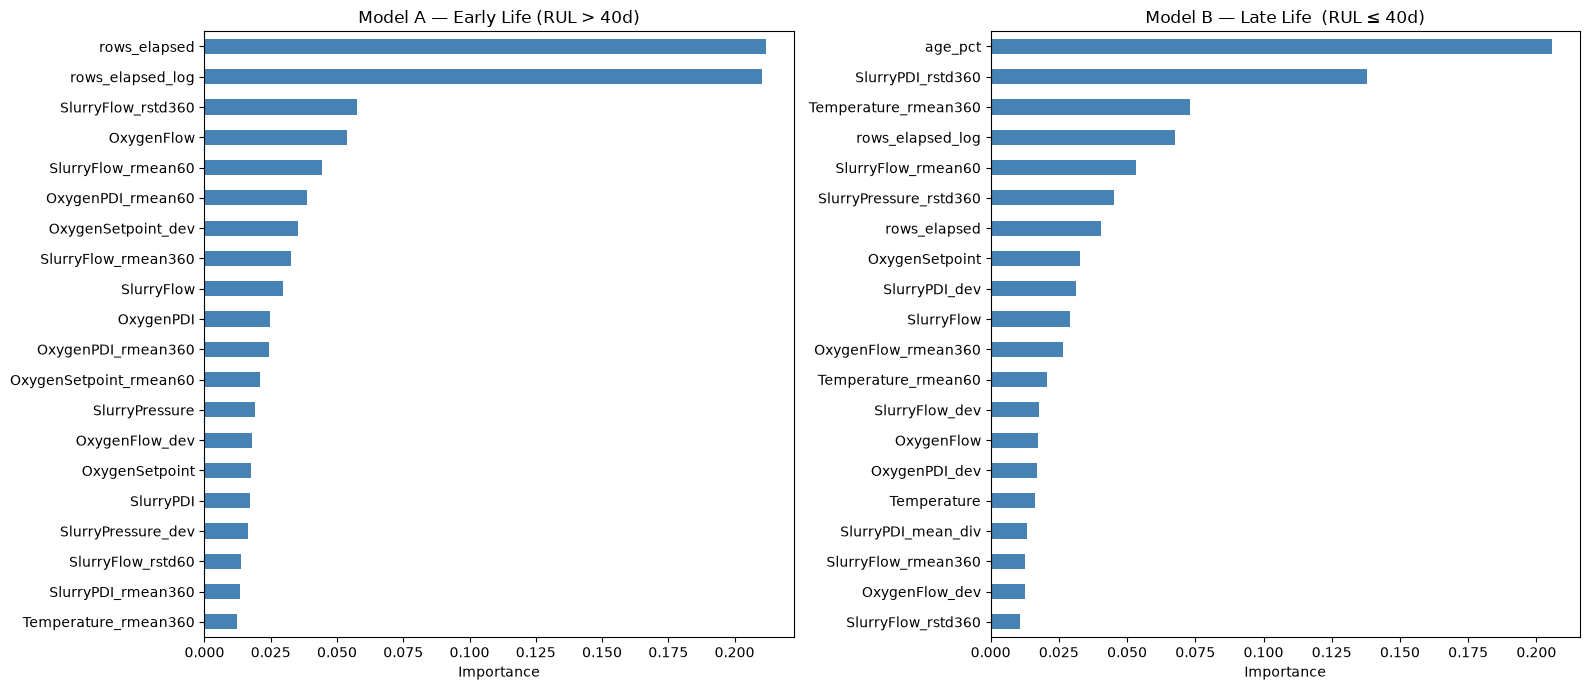

Top 10 — Model A:
rows_elapsed           0.211766
rows_elapsed_log       0.210197
SlurryFlow_rstd360     0.057580
OxygenFlow             0.053696
SlurryFlow_rmean60     0.044407
OxygenPDI_rmean60      0.038653
OxygenSetpoint_dev     0.035449
SlurryFlow_rmean360    0.032673
SlurryFlow             0.029696
OxygenPDI              0.024693

Top 10 — Model B:
age_pct                   0.205697
SlurryPDI_rstd360         0.137762
Temperature_rmean360      0.073148
rows_elapsed_log          0.067561
SlurryFlow_rmean60        0.053100
SlurryPressure_rstd360    0.045304
rows_elapsed              0.040516
OxygenSetpoint            0.032927
SlurryPDI_dev             0.031184
SlurryFlow                0.029129


In [31]:
# ── 6. FEATURE IMPORTANCE ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, features, title in [
    (axes[0], final_A, FEATURES_A, 'Model A — Early Life (RUL > 40d)'),
    (axes[1], final_B, FEATURES_B, 'Model B — Late Life  (RUL ≤ 40d)'),
]:
    fi = pd.Series(model.feature_importances_, index=features)
    fi.sort_values(ascending=False).head(20).plot(
        kind='barh', ax=ax, color='steelblue')
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig("feature_importance_final.png", dpi=100)
plt.show()

print("Top 10 — Model A:")
fi_a = pd.Series(final_A.feature_importances_, index=FEATURES_A)
print(fi_a.sort_values(ascending=False).head(10).to_string())

print("\nTop 10 — Model B:")
fi_b = pd.Series(final_B.feature_importances_, index=FEATURES_B)
print(fi_b.sort_values(ascending=False).head(10).to_string())


## Step 7 — Save Bundle

In [32]:
# ── 7. SAVE BUNDLE ───────────────────────────────────────────────────────────
bundle = {
    # Models
    'model_A':    final_A,
    'model_B':    final_B,

    # Feature lists (inference must use these exact lists)
    'features_A': FEATURES_A,
    'features_B': FEATURES_B,

    # Config
    'rul_split':     RUL_SPLIT,
    'sensors':       SENSORS,
    'window_short':  WINDOW_SHORT,
    'window_long':   WINDOW_LONG,

    # Cross-validation results (for reporting)
    'cv_mean_mae': round(ok['mae_overall'].mean(), 2),
    'cv_std_mae':  round(ok['mae_overall'].std(), 2),
    'cv_per_run':  ok.set_index('holdout')['mae_overall'].to_dict(),
}

joblib.dump(bundle, BUNDLE_PATH)
print(f"Saved → {BUNDLE_PATH}")
print(f"\nModel A: {len(FEATURES_A)} features")
print(f"Model B: {len(FEATURES_B)} features")
print(f"Cross-validated MAE: {bundle['cv_mean_mae']} ± {bundle['cv_std_mae']} days")
print(f"Late-life MAE (RUL ≤ 40d): ~4-11 days across all runs")


Saved → rul_bundle_v5_excluding_g5r19.joblib

Model A: 62 features
Model B: 63 features
Cross-validated MAE: 11.13 ± 4.78 days
Late-life MAE (RUL ≤ 40d): ~4-11 days across all runs
